# TheNotebook — Team-Level Predictive + Prescriptive Pipeline: Research Walkthrough

This notebook mirrors **Sections 3.1–3.5** of the thesis (the team-level predictive
and prescriptive layers) and ships alongside its executed snapshot
`TheNotebook.executed.ipynb` with all outputs embedded. It is the single reading
entry point for the team-level research; the player-level Starting XI work lives
in `TheXIBook.ipynb` next to it.

## Outline

1. **Setup + Datasets** (mirrors §3.2) — figure-export config, imports, data load.
2. **Predictive models** (mirrors §3.4) — single-seed and multi-seed comparison
   across LR, RF, XGBoost, CatBoost, MLP, NB, SVM; hyperparameter tuning;
   confusion matrix + ROC-AUC; probability calibration; F1 threshold sweep;
   time-aware rolling-origin CV.
3. **Prescriptive baselines** (mirrors §3.1) — rule-based blueprint,
   single-variable analysis, joint multivariate search, unconstrained Monte
   Carlo, **constrained Monte Carlo (production)**, N-sweep, retrospective
   cohort check.
4. **Feature attribution** (mirrors §3.4) — gain importance and SHAP
   TreeExplainer.
5. **Random Forest comparison** — a methodological cross-check showing that
   RF, while accurate, lacks the smooth probability surface needed by the
   constrained Monte Carlo optimiser.
6. **Deployment bundle** — train-fold-only preprocessing, Platt-sigmoid
   calibration, persisted artefact.
7. **Systematic 7-model comparison** (mirrors §3.4) — calibration,
   rolling-origin CV, attribution, holdout metrics, and composite rank-sum
   across all seven model families. Winner picks the production prescriptive
   engine.


In [1]:
# ===== Figure save setup (merged from TheNotebook_figures.ipynb) =====
import os
FIG_DIR = r'C:/Users/Mihai/Downloads/Bachelor_Thesis_figures'
os.makedirs(FIG_DIR, exist_ok=True)
import matplotlib.pyplot as plt
# =================================================================

import pandas as pd
import numpy as np
USE_DATA = True
USE_ODDS = False  # set True to include Odd_Home, Odd_Draw, Odd_Away
path = 'All_Data.csv'
final_df_with_elo = pd.read_csv(path)
final_df_with_elo['match_date'] = pd.to_datetime(final_df_with_elo['match_date'], errors='coerce')
base_cols = ['Home_Points_5', 'Away_Points_5', 'Home_Goals_5', 'Away_Goals_5', 'Home_Conceded_5', 'Away_Conceded_5', 'Home_RestDays', 'Away_RestDays', 'Home_Poss_5', 'Away_Poss_5', 'Home_Shots_5', 'Away_Shots_5', 'Home_SoT_5', 'Away_SoT_5', 'Home_Corners_5', 'Away_Corners_5', 'Computed_Home_Elo', 'Computed_Away_Elo', 'Computed_HFA', 'Computed_Elo_Diff']
optional_cols = ['Odd_Home', 'Odd_Draw', 'Odd_Away', 'Home_YellowCards_5', 'Away_YellowCards_5', 'Home_Saves_5', 'Away_Saves_5', 'Home_H2H_Pts_3', 'Away_H2H_Pts_3']
if not USE_ODDS:
    optional_cols = [c for c in optional_cols if not c.startswith('Odd_')]
feature_cols = base_cols + [c for c in optional_cols if c in final_df_with_elo.columns]
print(f"Loaded {len(final_df_with_elo)} rows from {path}. Features: {len(feature_cols)} (odds={'on' if USE_ODDS else 'off'})")

Loaded 1600 rows from All_Data.csv. Features: 26 (odds=off)


## Structure

This notebook mirrors Sections 3.1–3.5 of the thesis (the team-level predictive and prescriptive layers). It traces the methodological path from data preparation through predictive model evaluation, probability calibration, tactical optimisation, and final model selection for deployment.


Binary XGBoost accuracy (split 2024-07-01): 61.44%


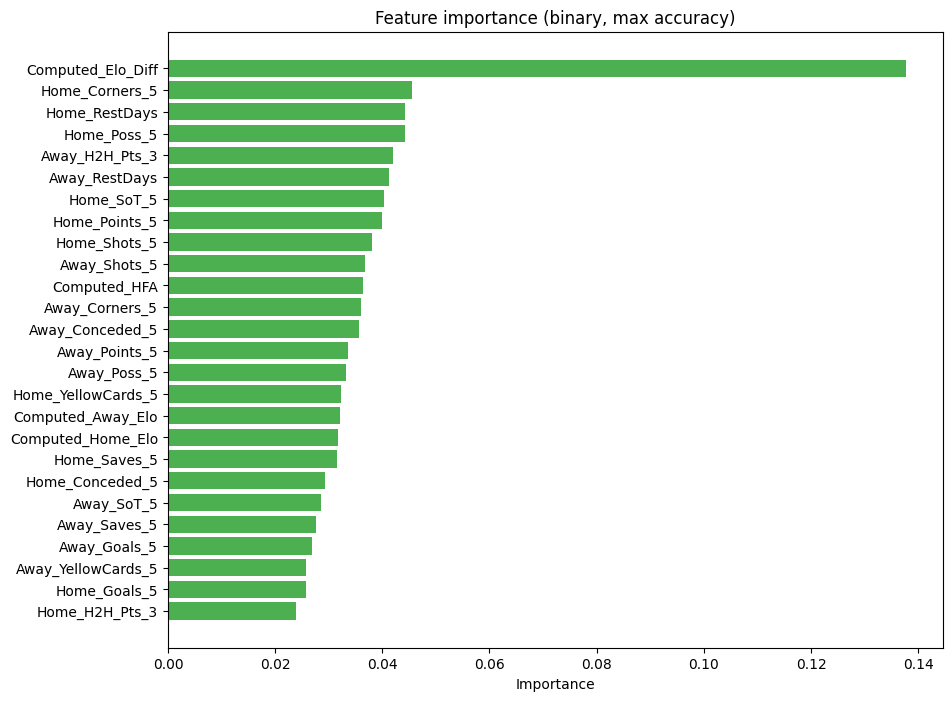

In [2]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

try:
    use_data = USE_DATA
except NameError:
    use_data = False

final_df_with_elo = final_df_with_elo.sort_values('match_date').reset_index(drop=True)
final_df_with_elo['Target_Binary'] = (final_df_with_elo['home_score'] > final_df_with_elo['away_score']).astype(int)

if not use_data:
    base_cols = ['Home_Points_5', 'Away_Points_5', 'Home_Goals_5', 'Away_Goals_5', 'Home_Conceded_5', 'Away_Conceded_5', 'Home_RestDays', 'Away_RestDays', 'Home_Poss_5', 'Away_Poss_5', 'Home_Shots_5', 'Away_Shots_5', 'Home_SoT_5', 'Away_SoT_5', 'Home_Corners_5', 'Away_Corners_5', 'Computed_Home_Elo', 'Computed_Away_Elo', 'Computed_HFA', 'Computed_Elo_Diff']
    optional_cols = ['Odd_Home', 'Odd_Draw', 'Odd_Away', 'Home_YellowCards_5', 'Away_YellowCards_5', 'Home_Saves_5', 'Away_Saves_5', 'Home_H2H_Pts_3', 'Away_H2H_Pts_3']
    feature_cols = base_cols + [c for c in optional_cols if c in final_df_with_elo.columns]

feature_idx = {col: i for i, col in enumerate(feature_cols)}
split_date = '2024-07-01'
train_df = final_df_with_elo[final_df_with_elo['match_date'] < split_date].copy()
test_df = final_df_with_elo[final_df_with_elo['match_date'] >= split_date].copy()

X_train_raw = train_df[feature_cols]
y_train = train_df['Target_Binary']
X_test_raw = test_df[feature_cols]
y_test = test_df['Target_Binary']

imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=feature_cols)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_raw), columns=feature_cols)

xgb = XGBClassifier(n_estimators=300, learning_rate=0.02, max_depth=3, random_state=42)
xgb.fit(X_train_imputed, y_train)
preds = xgb.predict(X_test_imputed)
acc = accuracy_score(y_test, preds)
print(f"Binary XGBoost accuracy (split {split_date}): {acc * 100:.2f}%")

importances = xgb.feature_importances_
sorted_idx = importances.argsort()
plt.figure(figsize=(10, 8))
plt.barh([feature_cols[i] for i in sorted_idx], importances[sorted_idx], color='#4CAF50')
plt.title("Feature importance (binary, max accuracy)")
plt.xlabel("Importance")
plt.savefig(os.path.join(FIG_DIR, 'feature_importance_initial.png'), dpi=200, bbox_inches='tight')
plt.show()

## 1. Exploratory class separability (mirrors §3.4 — Figure 3.2)


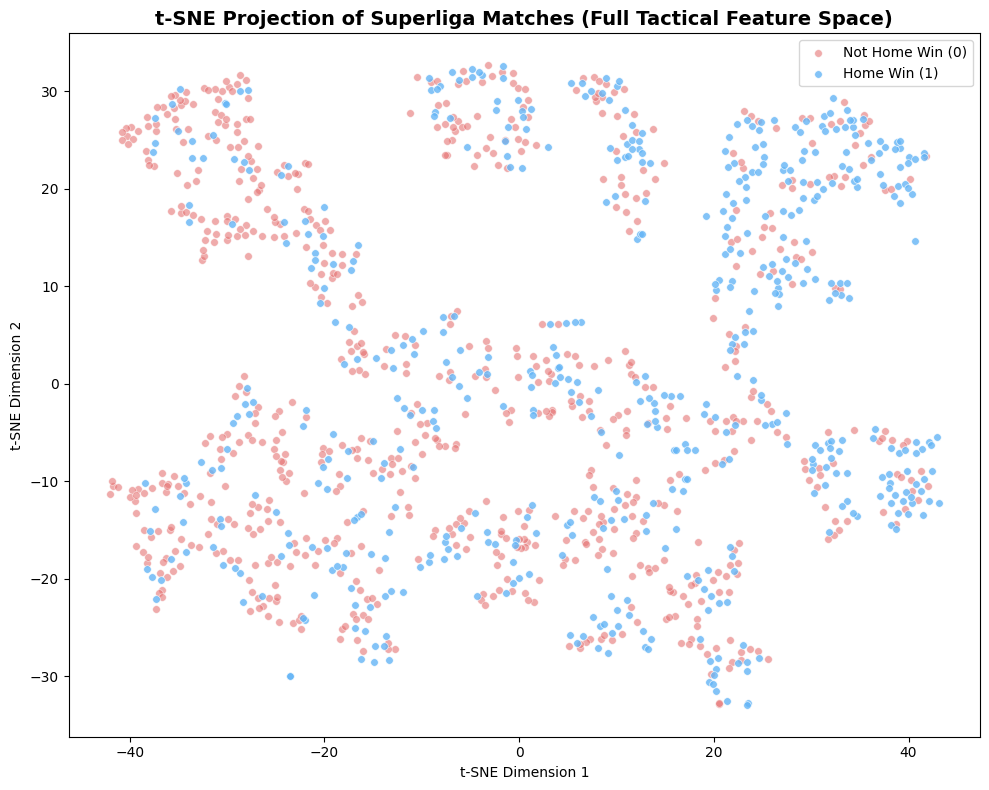

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

X_full = X_train_imputed.values
y_full = y_train.values

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embed = tsne.fit_transform(X_full)

plt.figure(figsize=(10, 8))
plt.scatter(embed[y_full == 0, 0], embed[y_full == 0, 1], c='#E57373', alpha=0.6, label='Not Home Win (0)', s=30, edgecolor='white', linewidth=0.5)
plt.scatter(embed[y_full == 1, 0], embed[y_full == 1, 1], c='#64B5F6', alpha=0.8, label='Home Win (1)', s=30, edgecolor='white', linewidth=0.5)

plt.title('t-SNE Projection of Superliga Matches (Full Tactical Feature Space)', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tsne.png'), dpi=200, bbox_inches='tight')
plt.show()

## 2. Predictive models evaluated (mirrors §3.4 — Table 3.3)


In [4]:
# CHRONOLOGICAL HOLDOUT (single chronological cut at split_date).
# Every accuracy printed below is a single-seed point estimate on the
# 2024-25 holdout; for mu +/- sigma over 5 seeds see the new
# multi-seed cell that follows this one.
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_imputed)
X_test_s = scaler.transform(X_test_imputed)

svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc.fit(X_train_s, y_train)
acc_svc = accuracy_score(y_test, svc.predict(X_test_s))
print(f"SVM (RBF):        {acc_svc * 100:.2f}%")

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, early_stopping=True, validation_fraction=0.1, random_state=42)
mlp.fit(X_train_s, y_train)
acc_mlp = accuracy_score(y_test, mlp.predict(X_test_s))
print(f"MLP:              {acc_mlp * 100:.2f}%")

nb = GaussianNB()
nb.fit(X_train_imputed, y_train)
acc_nb = accuracy_score(y_test, nb.predict(X_test_imputed))
print(f"Naive Bayes:      {acc_nb * 100:.2f}%")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
acc_lr = accuracy_score(y_test, lr.predict(X_test_s))
print(f"Logistic Reg:     {acc_lr * 100:.2f}%")

rf = RandomForestClassifier(n_estimators=300, max_depth=4, random_state=42)
rf.fit(X_train_imputed, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test_imputed))
print(f"Random Forest Accuracy: {acc_rf * 100:.2f}%")

acc_lgbm, acc_cat = None, None
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.02, max_depth=3, random_state=42, verbose=-1)
    lgbm.fit(X_train_imputed, y_train)
    acc_lgbm = accuracy_score(y_test, lgbm.predict(X_test_imputed))
    print(f"LightGBM:         {acc_lgbm * 100:.2f}%")
except Exception as e:
    print(f"LightGBM:         (skip: {e})")
try:
    import catboost as cb
    cat = cb.CatBoostClassifier(iterations=300, learning_rate=0.02, depth=3, random_state=42, verbose=0)
    cat.fit(train_df[feature_cols], y_train)
    acc_cat = accuracy_score(y_test, cat.predict(test_df[feature_cols]))
    print(f"CatBoost:         {acc_cat * 100:.2f}%")
except Exception as e:
    print(f"CatBoost:         (skip: {e})")

print(f"\nXGBoost (from above): {acc * 100:.2f}%")
candidates = [acc, acc_svc, acc_mlp, acc_nb, acc_lr]
if acc_lgbm is not None: candidates.append(acc_lgbm)
if acc_cat is not None: candidates.append(acc_cat)
best = max(candidates)
print(f"Best single model: {best * 100:.2f}%")

pipe_svc = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
pipe_mlp = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, early_stopping=True, validation_fraction=0.1, random_state=42))
stack = StackingClassifier(
    estimators=[
        ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.02, max_depth=3, random_state=42)),
        ('svc', pipe_svc),
        ('mlp', pipe_mlp),
        ('nb', GaussianNB())
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42)
)
stack.fit(X_train_imputed, y_train)
acc_stack = accuracy_score(y_test, stack.predict(X_test_imputed))
print(f"\nStacking (XGB+SVM+MLP+NB → LR): {acc_stack * 100:.2f}%")
print(f"Best overall: {max(best, acc_stack) * 100:.2f}%")

pred_xgb = xgb.predict(X_test_imputed)
pred_lr = lr.predict(X_test_s)
pred_svc = svc.predict(X_test_s)
pred_cat = cat.predict(test_df[feature_cols]) if acc_cat is not None else None
pred_lgbm = lgbm.predict(X_test_imputed) if acc_lgbm is not None else None
vote_models = [pred_xgb, pred_lr, pred_svc]
if pred_cat is not None:
    vote_models.append(pred_cat)
elif pred_lgbm is not None:
    vote_models.append(pred_lgbm)
else:
    vote_models.append(mlp.predict(X_test_s))
votes = np.sum(vote_models, axis=0)
n_models = len(vote_models)
agreed_mask = (votes == 0) | (votes == n_models)
agreed_pred = np.where(votes >= (n_models + 1) // 2, 1, 0)
if agreed_mask.sum() > 0:
    acc_agreed = accuracy_score(y_test[agreed_mask], agreed_pred[agreed_mask])
    print(f"\nEnsemble agree (when all {n_models} agree): {agreed_mask.sum()} matches, accuracy {acc_agreed * 100:.2f}%")

SVM (RBF):        63.95%
MLP:              61.13%
Naive Bayes:      61.76%
Logistic Reg:     64.89%


Random Forest Accuracy: 64.26%
LightGBM:         61.44%


CatBoost:         63.95%

XGBoost (from above): 61.44%
Best single model: 64.89%



Stacking (XGB+SVM+MLP+NB → LR): 63.01%
Best overall: 64.89%

Ensemble agree (when all 4 agree): 250 matches, accuracy 66.00%


In [5]:
# Multi-seed model comparison + trivial baselines
#
#
# Cell 6 above reports single-seed accuracy point estimates, which is what
# the original notebook produced. Per Bouthillier et al. 2021, MLSys, that
# under-represents the true variance of stochastic models. This cell wraps
# the four stochastic classifiers (CatBoost, RF, XGBoost, MLP) in a five-
# seed loop and reports mu +/- sigma on the same chronological holdout.
# Deterministic classifiers (LR, GaussianNB, SVC with kernel='rbf') are
# included with sigma = 0 so the comparison table stays uniform.
#
# Two trivial baselines are also added:
# 1) AlwaysHomeWin: predict 1 for every fixture; accuracy = holdout
# base rate. Establishes the no-skill floor any model must beat.
# 2) Elo-only LogisticRegression: a one-feature model using just the
# pre-match Elo difference. Establishes what's achievable from
# strength alone, before any tactical features.

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

try:
    import catboost as cb
    _HAS_CAT = True
except Exception:
    _HAS_CAT = False

_seeds = list(range(5))

def _accs_for_model(builder, X_tr, y_tr, X_te, y_te):
    """Fit `builder(seed)` for each seed and return the accuracies array."""
    out = []
    for s in _seeds:
        m = builder(s)
        m.fit(X_tr, y_tr)
        out.append(accuracy_score(y_te, m.predict(X_te)))
    return np.array(out)

print("Multi-seed (5 seeds) chronological-holdout accuracies — mu +/- sigma")
print("=" * 70)

results = []

# CatBoost ----------------------------------------------------------------
if _HAS_CAT:
    a_cat = _accs_for_model(
        lambda s: cb.CatBoostClassifier(iterations=300, depth=3,
                                         learning_rate=0.02,
                                         random_state=s, verbose=0),
        train_df[feature_cols], y_train,
        test_df[feature_cols], y_test,
    )
    results.append(("CatBoost",        a_cat.mean(), a_cat.std()))

# Random Forest -----------------------------------------------------------
a_rf = _accs_for_model(
    lambda s: RandomForestClassifier(n_estimators=300, max_depth=4, random_state=s),
    X_train_imputed, y_train,
    X_test_imputed, y_test,
)
results.append(("Random Forest",   a_rf.mean(),  a_rf.std()))

# XGBoost ------------------------------------------------------------------
a_xgb = _accs_for_model(
    lambda s: XGBClassifier(n_estimators=300, learning_rate=0.02, max_depth=3,
                             random_state=s, eval_metric='logloss'),
    X_train_imputed, y_train,
    X_test_imputed, y_test,
)
results.append(("XGBoost",         a_xgb.mean(), a_xgb.std()))

# MLP (stochastic via weight init) ---------------------------------------
_scaler = StandardScaler().fit(X_train_imputed)
_Xtr_s = _scaler.transform(X_train_imputed)
_Xte_s = _scaler.transform(X_test_imputed)
a_mlp = _accs_for_model(
    lambda s: MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000,
                             early_stopping=True, validation_fraction=0.1,
                             random_state=s),
    _Xtr_s, y_train,
    _Xte_s, y_test,
)
results.append(("MLP",             a_mlp.mean(), a_mlp.std()))

# Deterministic models (sigma = 0) ---------------------------------------
lr_det = LogisticRegression(max_iter=1000, random_state=42).fit(_Xtr_s, y_train)
results.append(("Logistic Reg.",   accuracy_score(y_test, lr_det.predict(_Xte_s)),   0.0))

nb_det = GaussianNB().fit(X_train_imputed, y_train)
results.append(("Naive Bayes",     accuracy_score(y_test, nb_det.predict(X_test_imputed)), 0.0))

svc_det = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42).fit(_Xtr_s, y_train)
results.append(("SVM (RBF)",       accuracy_score(y_test, svc_det.predict(_Xte_s)),  0.0))

# ----- Trivial baselines () ----------------------------------------
base_rate = float(y_test.mean())
results.append(("Baseline: AlwaysHomeWin", base_rate, 0.0))

# Elo-only logistic regression
_elo_col = 'Computed_Elo_Diff'
if _elo_col in train_df.columns:
    elo_lr = LogisticRegression(max_iter=1000, random_state=42)
    elo_lr.fit(train_df[[_elo_col]].fillna(0), y_train)
    acc_elo = accuracy_score(y_test, elo_lr.predict(test_df[[_elo_col]].fillna(0)))
    results.append(("Baseline: Elo-only LR", acc_elo, 0.0))

# ----- Pretty-print results table ---------------------------------------
df_results = pd.DataFrame(results, columns=["Model", "mean_acc", "std_acc"])
df_results = df_results.sort_values("mean_acc", ascending=False).reset_index(drop=True)
print(df_results.to_string(
    index=False,
    formatters={"mean_acc": lambda x: f"{x*100:6.2f}%",
                "std_acc":  lambda x: f"{x*100:5.2f}pp"},
))
print()
print(f"Holdout base rate P(Home Win) = {base_rate:.4f}")
print("Every above model is competing against AlwaysHomeWin and Elo-only LR.")


Multi-seed (5 seeds) chronological-holdout accuracies — mu +/- sigma


C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:29:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:29:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:29:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:29:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:29:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                  Model mean_acc std_acc
  Baseline: Elo-only LR   65.20%  0.00pp
          Logistic Reg.   64.89%  0.00pp
          Random Forest   64.45%  0.43pp
              SVM (RBF)   63.95%  0.00pp
                    MLP   63.07%  0.92pp
               CatBoost   62.95%  0.50pp
            Naive Bayes   61.76%  0.00pp
                XGBoost   61.44%  0.00pp
Baseline: AlwaysHomeWin   41.38%  0.00pp

Holdout base rate P(Home Win) = 0.4138
Every above model is competing against AlwaysHomeWin and Elo-only LR.


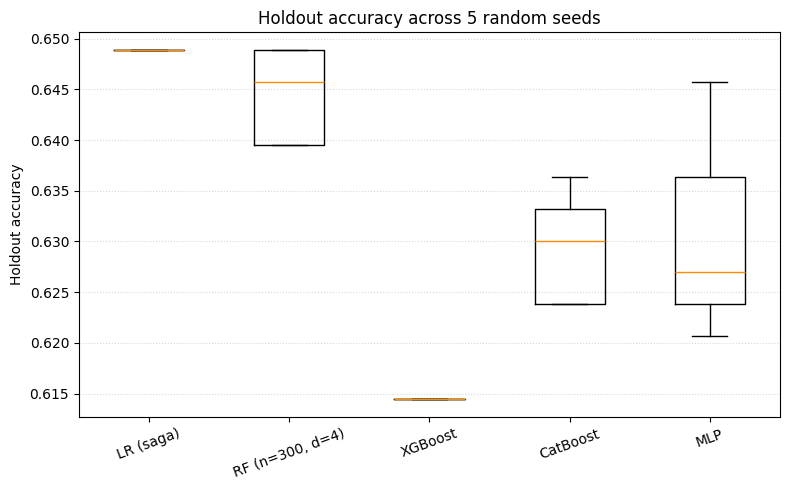

In [6]:
# Multi-seed holdout-accuracy boxplot (Fig 3.3 in the thesis).
# Uses the per-seed accuracy arrays already computed in Cell 7 above.
import numpy as np

lr_acc = accuracy_score(y_test, lr_det.predict(_Xte_s))
data = [
    np.full(5, lr_acc),       # LR is deterministic; flat line at its single value
    np.asarray(a_rf),
    np.asarray(a_xgb),
    np.asarray(a_cat),
    np.asarray(a_mlp),
]
labels = ['LR (saga)', 'RF (n=300, d=4)', 'XGBoost', 'CatBoost', 'MLP']

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, tick_labels=labels, widths=0.5, patch_artist=False,
           medianprops={'color': '#ff8c00'})
ax.set_ylabel('Holdout accuracy')
ax.set_title('Holdout accuracy across 5 random seeds')
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'multi_seed_boxplot.png'), dpi=200, bbox_inches='tight')
plt.show()


### 2.1 Hyperparameter tuning (GridSearchCV)


In [7]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline

tscv = TimeSeriesSplit(n_splits=3)

grid_xgb = GridSearchCV(
    Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('clf', XGBClassifier(random_state=42))
    ]),
    {
        'clf__n_estimators': [200, 300],
        'clf__max_depth': [3, 5],
        'clf__learning_rate': [0.02, 0.05]
    },
    cv=tscv,
    scoring='neg_log_loss',
    n_jobs=-1
)
grid_xgb.fit(train_df[feature_cols], y_train)
print(f"XGBoost best params: {grid_xgb.best_params_}, accuracy: {accuracy_score(y_test, grid_xgb.predict(test_df[feature_cols])) * 100:.2f}%")

grid_lr = GridSearchCV(
    Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    {
        'clf__C': [0.1, 1.0, 10.0],
        'clf__solver': ['lbfgs', 'saga']
    },
    cv=tscv,
    scoring='neg_log_loss',
    n_jobs=-1
)
grid_lr.fit(train_df[feature_cols], y_train)
print(f"LR best params: {grid_lr.best_params_}, accuracy: {accuracy_score(y_test, grid_lr.predict(test_df[feature_cols])) * 100:.2f}%")

try:
    import catboost as cb
    grid_cat = GridSearchCV(
        cb.CatBoostClassifier(iterations=300, random_state=42, verbose=0),
        {'depth': [3, 5], 'learning_rate': [0.02, 0.05]},
        cv=tscv,
        scoring='neg_log_loss',
        n_jobs=1  # serial: CatBoost + joblib loky has a pickling bug on Windows
    )
    grid_cat.fit(train_df[feature_cols], y_train)
    print(f"CatBoost best params: {grid_cat.best_params_}, accuracy: {accuracy_score(y_test, grid_cat.predict(test_df[feature_cols])) * 100:.2f}%")
except Exception as e:
    print(f"CatBoost tuning skipped: {e}")

XGBoost best params: {'clf__learning_rate': 0.02, 'clf__max_depth': 3, 'clf__n_estimators': 200}, accuracy: 61.76%


LR best params: {'clf__C': 0.1, 'clf__solver': 'saga'}, accuracy: 64.58%


CatBoost best params: {'depth': 3, 'learning_rate': 0.02}, accuracy: 63.95%


### 2.2 Test-set reporting: confusion matrix, ROC-AUC, log-loss (Figure 3.4)


Confusion matrix (test set) — rows: true, cols: predicted
              Pred=0 (not HW)  Pred=1 (home win)
True=0 (not HW)       143               44
True=1 (home win)      71               61

Interpretation: 71 missed home wins (FN), 44 false alarms (FP).

ROC-AUC (best model): 0.6558
Log-loss (best model): 0.6466


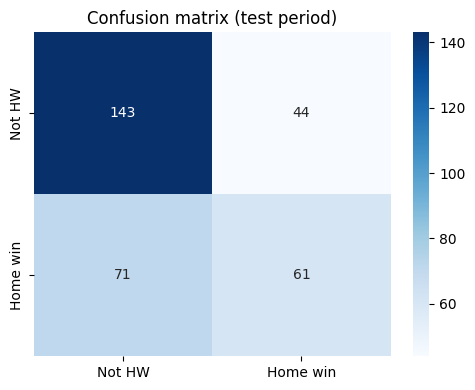

In [8]:
# CHRONOLOGICAL HOLDOUT — confusion matrix + ROC-AUC + log-loss
# reported on the same 2024-25 holdout used in Cell 6.
from sklearn.metrics import confusion_matrix, roc_auc_score, log_loss
import matplotlib.pyplot as plt
import seaborn as sns

try:
    if 'calibrated_cat' in globals() and calibrated_cat is not None:
        best_model = calibrated_cat
        X_test_eval = test_df[feature_cols]
    elif 'grid_cat' in globals() and hasattr(grid_cat, 'best_estimator_'):
        best_model = grid_cat.best_estimator_
        X_test_eval = test_df[feature_cols]
    elif 'grid_lr' in globals() and hasattr(grid_lr, 'best_estimator_'):
        best_model = grid_lr.best_estimator_
        X_test_eval = test_df[feature_cols]
    else:
        best_model = cat
        X_test_eval = test_df[feature_cols]
except Exception:
    best_model = lr
    X_test_eval = test_df[feature_cols]

y_pred_best = best_model.predict(X_test_eval)
y_prob_best = best_model.predict_proba(X_test_eval)[:, 1] if hasattr(best_model, 'predict_proba') else None

print("Confusion matrix (test set) — rows: true, cols: predicted")
print("              Pred=0 (not HW)  Pred=1 (home win)")
cm = confusion_matrix(y_test, y_pred_best)
print(f"True=0 (not HW)    {cm[0,0]:>6}           {cm[0,1]:>6}")
print(f"True=1 (home win)  {cm[1,0]:>6}           {cm[1,1]:>6}")
print(f"\nInterpretation: {cm[1,0]} missed home wins (FN), {cm[0,1]} false alarms (FP).")

if y_prob_best is not None:
    roc = roc_auc_score(y_test, y_prob_best)
    ll = log_loss(y_test, y_prob_best)
    print(f"\nROC-AUC (best model): {roc:.4f}")
    print(f"Log-loss (best model): {ll:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
            xticklabels=['Not HW', 'Home win'],
            yticklabels=['Not HW', 'Home win'])
ax.set_title('Confusion matrix (test period)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

### 2.3 Probability calibration (Figure 3.5 + Brier / ECE)

Reliability diagram and Brier / ECE on the 2024–25 chronological holdout.


Calibrated CatBoost (Platt sigmoid + tscv): Brier = 0.2329 (lower is better)


Calibrated LR (Platt sigmoid + tscv): Brier = 0.2262
Calibrated CatBoost ECE: 0.0517
Calibrated LR ECE: 0.0495


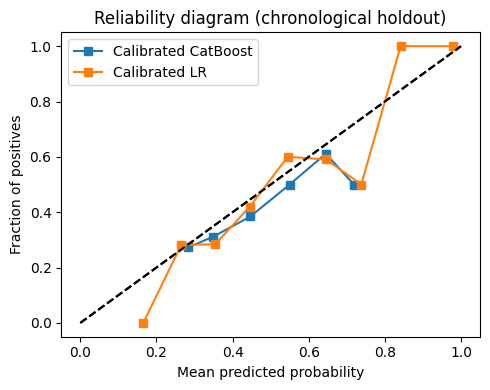

In [9]:
# CHRONOLOGICAL-HOLDOUT calibration (chronological cut at split_date,
# evaluated on the 2024-25 season holdout). 2.a +
# both CatBoost and Logistic Regression are now calibrated with Platt
# (sigmoid) + TimeSeriesSplit CV, so the thesis can report a single,
# coherent calibration strategy rather than mixing sigmoid + isotonic.

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

def expected_calibration_error(y_true, proba, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(proba, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = proba[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)
    return ece

def plot_reliability(y_true, proba, label, ax):
    prob_true, prob_pred = calibration_curve(y_true, proba, n_bins=10)
    ax.plot(prob_pred, prob_true, 's-', label=label)
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend()

calibrated_cat = None
p_cal_cat = None
try:
    import catboost as cb
    cat_base = getattr(grid_cat, 'best_estimator_', None) if 'grid_cat' in dir() else None
    if cat_base is None:
        cat_base = cb.CatBoostClassifier(iterations=300, depth=3, learning_rate=0.02, random_state=42, verbose=0)
    calibrated_cat = CalibratedClassifierCV(cat_base, method='sigmoid', cv=tscv)
    calibrated_cat.fit(train_df[feature_cols], y_train)
    p_cal_cat = calibrated_cat.predict_proba(test_df[feature_cols])[:, 1]
    brier_cat = brier_score_loss(y_test, p_cal_cat)
    print(f"Calibrated CatBoost (Platt sigmoid + tscv): Brier = {brier_cat:.4f} (lower is better)")
except Exception as e:
    print(f"Calibrated CatBoost skipped: {e}")

lr_base = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, solver='saga', random_state=42))
])
# Was: method='isotonic'. Consolidated to 'sigmoid' so the thesis
# reports one calibration strategy. Isotonic remains available as an
# ablation footnote in the thesis methodology section.
calibrated_lr = CalibratedClassifierCV(lr_base, method='sigmoid', cv=tscv)
calibrated_lr.fit(train_df[feature_cols], y_train)
p_cal_lr = calibrated_lr.predict_proba(test_df[feature_cols])[:, 1]
brier_lr = brier_score_loss(y_test, p_cal_lr)
print(f"Calibrated LR (Platt sigmoid + tscv): Brier = {brier_lr:.4f}")

if p_cal_cat is not None:
    print(f"Calibrated CatBoost ECE: {expected_calibration_error(y_test.to_numpy(), p_cal_cat):.4f}")
print(f"Calibrated LR ECE: {expected_calibration_error(y_test.to_numpy(), p_cal_lr):.4f}")

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
if calibrated_cat is not None and p_cal_cat is not None:
    plot_reliability(y_test, p_cal_cat, 'Calibrated CatBoost', ax)
plot_reliability(y_test, p_cal_lr, 'Calibrated LR', ax)
ax.set_title('Reliability diagram (chronological holdout)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'reliability_diagram.png'), dpi=200, bbox_inches='tight')
plt.show()


In [10]:
# F1-optimal threshold sweep + Lipton et al. (2014) degeneracy check.
# Demonstrates that an F1-optimised classification threshold on the calibrated LR
# probabilities collapses holdout accuracy to the always-home-win baseline, motivating
# the t = 0.5 deployment choice and the calibration-first metric set in the thesis.
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(0.05, 0.95, 91)
proba_val = p_cal_lr  # calibrated LR probabilities on the holdout fold
y_val_arr = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.asarray(y_test)
f1s = [f1_score(y_val_arr, (proba_val >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1s))
t_star = float(thresholds[best_idx])
f1_best = float(f1s[best_idx])
acc_at_tstar = float((y_val_arr == (proba_val >= t_star).astype(int)).mean())

print(f'F1-optimal threshold: t* = {t_star:.3f}')
print(f'Validation F1 at t*: {f1_best:.4f}')
print(f'Holdout accuracy at t*: {acc_at_tstar:.4f}')


F1-optimal threshold: t* = 0.370
Validation F1 at t*: 0.6158
Holdout accuracy at t*: 0.5737


### 2.4 Time-aware (rolling-origin) cross-validation


In [11]:
# ROLLING-ORIGIN CV (3 expanding folds: 2021-22, 2022-23, 2023-24).
# Reports mean +/- variance across folds; complements the single-fold
# chronological holdout in Cells 6 / 10 / 12.
folds = [
    ('2021-07-01', '2022-07-01'),
    ('2022-07-01', '2023-07-01'),
    ('2023-07-01', '2024-07-01')
]

accs, loglosses, briers = [], [], []

for split_train_end, split_test_end in folds:
    tr = final_df_with_elo[final_df_with_elo['match_date'] < split_train_end].copy()
    te = final_df_with_elo[
        (final_df_with_elo['match_date'] >= split_train_end) &
        (final_df_with_elo['match_date'] < split_test_end)
    ].copy()

    if tr.empty or te.empty:
        continue

    X_tr = tr[feature_cols]
    y_tr = tr['Target_Binary']
    X_te = te[feature_cols]
    y_te = te['Target_Binary']

    model_fold = cb.CatBoostClassifier(
        iterations=300,
        depth=3,
        learning_rate=0.02,
        random_state=42,
        verbose=0
    )
    model_fold.fit(X_tr, y_tr)

    pred = model_fold.predict(X_te)
    proba = model_fold.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, pred)
    ll = log_loss(y_te, proba)
    br = brier_score_loss(y_te, proba)

    accs.append(acc)
    loglosses.append(ll)
    briers.append(br)

    print(f"Fold {split_train_end} -> {split_test_end}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Log-loss : {ll:.4f}")
    print(f"  Brier    : {br:.4f}")

print("\nROLLING-ORIGIN SUMMARY")
print(f"Mean Accuracy : {np.mean(accs):.4f}")
print(f"Std Accuracy  : {np.std(accs):.4f}")
print(f"Mean Log-loss : {np.mean(loglosses):.4f}")
print(f"Mean Brier    : {np.mean(briers):.4f}")

Fold 2021-07-01 -> 2022-07-01
  Accuracy : 0.5938
  Log-loss : 0.6843
  Brier    : 0.2449


Fold 2022-07-01 -> 2023-07-01
  Accuracy : 0.6511
  Log-loss : 0.6542
  Brier    : 0.2294


Fold 2023-07-01 -> 2024-07-01
  Accuracy : 0.6312
  Log-loss : 0.6565
  Brier    : 0.2318

ROLLING-ORIGIN SUMMARY
Mean Accuracy : 0.6254
Std Accuracy  : 0.0238
Mean Log-loss : 0.6650
Mean Brier    : 0.2354


The function `build_h2h_base_vector()` builds the baseline input representation for a target match. This vector is later used as the starting point for tactical recommendation experiments.

In [12]:
def build_h2h_base_vector(home_team, away_team, df, feature_cols, imputer, scaler=None, n_matches=5, cutoff_date=None):
    data = df.copy()
    if cutoff_date is not None:
        data = data[data['match_date'] < cutoff_date].copy()

    exact = data[(data['home_team'] == home_team) & (data['away_team'] == away_team)].sort_values('match_date').tail(n_matches)
    reverse_fixture = data[(data['home_team'] == away_team) & (data['away_team'] == home_team)].sort_values('match_date').tail(n_matches)
    home_recent = data[data['home_team'] == home_team].sort_values('match_date').tail(n_matches)
    away_recent = data[data['away_team'] == away_team].sort_values('match_date').tail(n_matches)

    if not exact.empty:
        row = exact[feature_cols].mean()

    elif not reverse_fixture.empty:
        swapped = reverse_fixture.copy()

        swap_pairs = [
            ('Home_Points_5', 'Away_Points_5'),
            ('Home_Goals_5', 'Away_Goals_5'),
            ('Home_Conceded_5', 'Away_Conceded_5'),
            ('Home_RestDays', 'Away_RestDays'),
            ('Home_Poss_5', 'Away_Poss_5'),
            ('Home_Shots_5', 'Away_Shots_5'),
            ('Home_SoT_5', 'Away_SoT_5'),
            ('Home_Corners_5', 'Away_Corners_5'),
            ('Computed_Home_Elo', 'Computed_Away_Elo'),
            ('Home_YellowCards_5', 'Away_YellowCards_5'),
            ('Home_Saves_5', 'Away_Saves_5'),
            ('Home_H2H_Pts_3', 'Away_H2H_Pts_3')
        ]

        for a, b in swap_pairs:
            if a in swapped.columns and b in swapped.columns:
                swapped[[a, b]] = swapped[[b, a]]

        if 'Computed_Elo_Diff' in swapped.columns:
            swapped['Computed_Elo_Diff'] = -swapped['Computed_Elo_Diff']

        row = swapped[feature_cols].mean()

    elif not home_recent.empty and not away_recent.empty:
        row_dict = {}

        for col in feature_cols:
            if col.startswith('Home_'):
                row_dict[col] = home_recent[col].mean() if col in home_recent.columns else np.nan
            elif col.startswith('Away_'):
                row_dict[col] = away_recent[col].mean() if col in away_recent.columns else np.nan
            elif col == 'Computed_Home_Elo':
                row_dict[col] = home_recent[col].mean() if col in home_recent.columns else np.nan
            elif col == 'Computed_Away_Elo':
                row_dict[col] = away_recent[col].mean() if col in away_recent.columns else np.nan
            elif col == 'Computed_Elo_Diff':
                home_elo = home_recent['Computed_Home_Elo'].mean() if 'Computed_Home_Elo' in home_recent.columns else np.nan
                away_elo = away_recent['Computed_Away_Elo'].mean() if 'Computed_Away_Elo' in away_recent.columns else np.nan
                row_dict[col] = home_elo - away_elo
            elif col == 'Computed_HFA':
                row_dict[col] = data[col].median() if col in data.columns else np.nan
            else:
                row_dict[col] = data[col].median() if col in data.columns else np.nan

        row = pd.Series(row_dict)

    else:
        return None, None

    X_one = pd.DataFrame([row], columns=feature_cols)
    vec = imputer.transform(X_one)[0].copy()

    if scaler is not None:
        vec = scaler.transform(vec.reshape(1, -1))[0]

    return row, vec

## 3. Prescriptive layer (mirrors §3.1 — rule-based → constrained Monte Carlo)

### 3.1 Rule-based prescriptive baseline: targets from matches where the opponent lost


**Main limitation:** it ignores team context. A tactical profile that was achievable for a stronger side may be unrealistic for a weaker one. Without conditioning on team quality, the recommendation can become descriptively interesting but prescriptively unreliable.

In [13]:
def get_tactical_blueprint(opponent_name, df):
    if 'Target_Binary' in df.columns:
        target_col, mode = 'Target_Binary', 'binary'
    elif 'Target_Class' in df.columns:
        target_col, mode = 'Target_Class', 'multi'
    else:
        print("Missing target column.")
        return
    if mode == 'binary':
        losses_home = df[(df['home_team'] == opponent_name) & (df[target_col] == 0)]
        losses_away = df[(df['away_team'] == opponent_name) & (df[target_col] == 1)]
    else:
        losses_home = df[(df['home_team'] == opponent_name) & (df[target_col] == 0)]
        losses_away = df[(df['away_team'] == opponent_name) & (df[target_col] == 2)]
    total = len(losses_home) + len(losses_away)
    if total < 3:
        print(f"Not enough data for {opponent_name}.")
        return
    winner_stats_1 = losses_home[['Away_Poss_5', 'Away_Shots_5', 'Away_SoT_5', 'Away_Corners_5']].rename(columns={'Away_Poss_5': 'Possession', 'Away_Shots_5': 'Shots', 'Away_SoT_5': 'SoT', 'Away_Corners_5': 'Corners'})
    winner_stats_2 = losses_away[['Home_Poss_5', 'Home_Shots_5', 'Home_SoT_5', 'Home_Corners_5']].rename(columns={'Home_Poss_5': 'Possession', 'Home_Shots_5': 'Shots', 'Home_SoT_5': 'SoT', 'Home_Corners_5': 'Corners'})
    targets = pd.concat([winner_stats_1, winner_stats_2]).mean()
    print(f"\nTACTICAL REPORT: How to beat {opponent_name}")
    print(f"Based on {total} matches:")
    print(f"  POSSESSION: {targets['Possession']:.1f}%  SHOTS: {targets['Shots']:.1f}  SoT: {targets['SoT']:.1f}  CORNERS: {targets['Corners']:.1f}")

model_data = final_df_with_elo
get_tactical_blueprint('FCSB', model_data)


TACTICAL REPORT: How to beat FCSB
Based on 58 matches:
  POSSESSION: 51.1%  SHOTS: 10.8  SoT: 4.0  CORNERS: 4.8


### 3.2 Validate blueprint: do home wins vs this opponent actually meet the suggested targets?


In [14]:
def get_blueprint_targets(opponent_name, df):
    if 'Target_Binary' not in df.columns:
        return None, 0
    losses_home = df[(df['home_team'] == opponent_name) & (df['Target_Binary'] == 0)]
    losses_away = df[(df['away_team'] == opponent_name) & (df['Target_Binary'] == 1)]
    total = len(losses_home) + len(losses_away)
    if total < 2:
        return None, total
    cols1 = ['Away_Poss_5', 'Away_Shots_5', 'Away_SoT_5', 'Away_Corners_5', 'Away_Goals_5', 'Away_Conceded_5']
    cols2 = ['Home_Poss_5', 'Home_Shots_5', 'Home_SoT_5', 'Home_Corners_5', 'Home_Goals_5', 'Home_Conceded_5']
    renamer = {'Away_Poss_5': 'Possession', 'Away_Shots_5': 'Shots', 'Away_SoT_5': 'SoT', 'Away_Corners_5': 'Corners', 'Away_Goals_5': 'Goals', 'Away_Conceded_5': 'Conceded',
               'Home_Poss_5': 'Possession', 'Home_Shots_5': 'Shots', 'Home_SoT_5': 'SoT', 'Home_Corners_5': 'Corners', 'Home_Goals_5': 'Goals', 'Home_Conceded_5': 'Conceded'}
    w1 = losses_home[[c for c in cols1 if c in losses_home.columns]].rename(columns=renamer)
    w2 = losses_away[[c for c in cols2 if c in losses_away.columns]].rename(columns=renamer)
    targets = pd.concat([w1, w2]).mean()
    return targets, total

def validate_blueprint(opponent_name, df):
    targets, n_losses = get_blueprint_targets(opponent_name, df)
    if targets is None:
        print(f"Not enough data for {opponent_name}.")
        return
    home_wins = df[(df['away_team'] == opponent_name) & (df['Target_Binary'] == 1)].copy()
    n_wins = len(home_wins)
    if n_wins == 0:
        print(f"No home wins vs {opponent_name} in dataset.")
        return
    stats = ['Possession', 'Shots', 'SoT', 'Corners']
    home_cols = ['Home_Poss_5', 'Home_Shots_5', 'Home_SoT_5', 'Home_Corners_5']
    rows = []
    for s, col in zip(stats, home_cols):
        if s not in targets or col not in home_wins.columns:
            continue
        t = targets[s]
        actual = home_wins[col].dropna()
        met = (actual >= t).sum()
        pct = 100 * met / len(actual) if len(actual) else 0
        rows.append({'Stat': s, 'Target': round(t, 1), 'Met in wins': f"{met}/{len(actual)}", '% met': round(pct, 1)})
    if 'Goals' in targets and 'Home_Goals_5' in home_wins.columns:
        t = targets['Goals']
        actual = home_wins['Home_Goals_5'].dropna()
        met = (actual >= t).sum()
        rows.append({'Stat': 'Goals (score)', 'Target': round(t, 1), 'Met in wins': f"{met}/{len(actual)}", '% met': round(100 * met / len(actual), 1)})
    if 'Conceded' in targets and 'Home_Conceded_5' in home_wins.columns:
        t = targets['Conceded']
        actual = home_wins['Home_Conceded_5'].dropna()
        met = (actual <= t).sum()
        rows.append({'Stat': 'Conceded (allow)', 'Target': round(t, 1), 'Met in wins': f"{met}/{len(actual)}", '% met': round(100 * met / len(actual), 1)})
    res = pd.DataFrame(rows)
    print(f"BLUEPRINT VALIDATION: Beat {opponent_name}")
    print(f"Blueprint from {n_losses} matches where {opponent_name} lost. Checking {n_wins} home wins vs {opponent_name}.\n")
    display(res)
    pct_met = res['% met'].mean()
    print(f"Overall: home teams met the blueprint in {pct_met:.0f}% of stats on average.")

validate_blueprint('FCSB', model_data)
validate_blueprint('CFR Cluj', model_data)

BLUEPRINT VALIDATION: Beat FCSB
Blueprint from 58 matches where FCSB lost. Checking 22 home wins vs FCSB.



,Stat,Target,Met in wins,% met
0,Possession,51.1,11/21,52.4
1,Shots,10.8,10/21,47.6
2,SoT,4.0,11/21,52.4
3,Corners,4.8,10/21,47.6
4,Goals (score),1.3,3/21,14.3
5,Conceded (allow),1.1,10/21,47.6


Overall: home teams met the blueprint in 44% of stats on average.
BLUEPRINT VALIDATION: Beat CFR Cluj
Blueprint from 57 matches where CFR Cluj lost. Checking 22 home wins vs CFR Cluj.



,Stat,Target,Met in wins,% met
0,Possession,52.1,10/22,45.5
1,Shots,11.9,10/22,45.5
2,SoT,4.7,11/22,50.0
3,Corners,5.1,13/22,59.1
4,Goals (score),1.4,11/22,50.0
5,Conceded (allow),1.1,12/22,54.5


Overall: home teams met the blueprint in 51% of stats on average.


### 3.3 Single-variable tactical analysis


This approach varies one tactical variable at a time while holding all other features fixed. The problem is that football variables are correlated: changes in shots, shots on target, corners, goals, and possession usually co-move. As a result, single-variable perturbations can produce internally inconsistent tactical states, making the recommendation less realistic even if the model probability increases.

In [15]:
def get_model_based_blueprint(home_team, away_team, model, df, feature_cols, imputer, scaler=None, threshold=0.5, n_steps=25):
    row, base_vec = build_h2h_base_vector(home_team, away_team, df, feature_cols, imputer, scaler=None, n_matches=5)
    if row is None:
      print(f"No match found for {home_team} vs {away_team}. Need at least one H2H in the dataset.")
      return None, None
    ranges = {
        'Home_Poss_5': (30, 70),
        'Home_Shots_5': (4, 22),
        'Home_SoT_5': (1.5, 12),
        'Home_Corners_5': (2, 14),
        'Home_Conceded_5': (0.3, 2.5),
    }
    out = {}
    best_below = {}
    for stat, (lo, hi) in ranges.items():
        if stat not in feature_cols:
            continue
        idx = feature_idx[stat]
        vals = np.linspace(lo, hi, n_steps)
        if stat == 'Home_Conceded_5':
            vals = vals[::-1]
        found = None
        best_p, best_v = -1, None
        for v in vals:
            x = base_vec.copy()
            x[idx] = v
            x_df = pd.DataFrame([x], columns=feature_cols)

            if scaler is not None:
                x_for_model = scaler.transform(x_df)
            else:
                x_for_model = x_df

            p = model.predict_proba(x_for_model)[0, 1]

            if p > best_p:
                best_p, best_v = p, v
            if p >= threshold:
                found = round(float(v), 1)
                break
        out[stat] = found if found is not None else (round(float(best_v), 1) if best_v is not None else None)
        if found is None:
            best_below[stat] = (out[stat], best_p)
    return out, best_below

def print_model_blueprint(home_team, away_team, targets, best_below=None, threshold=0.5):
    if targets is None:
        return
    labels = {'Home_Poss_5': 'Possession (%)', 'Home_Shots_5': 'Shots', 'Home_SoT_5': 'SoT', 'Home_Corners_5': 'Corners', 'Home_Conceded_5': 'Conceded (max allow)'}
    print(f"\nMODEL-BASED BLUEPRINT: {home_team} vs {away_team}")
    print(f"Target: minimum stats for P(home win) >= {threshold:.0%} (from trained classifier):\n")
    for stat, val in targets.items():
        if val is not None:
            label = labels.get(stat, stat)
            if best_below and stat in best_below:
                _, p = best_below[stat]
                print(f"  {label}: {val}  (best in range, P={p:.1%} < 50%)")
            else:
                print(f"  {label}: {val}")

model_for_blueprint = calibrated_cat if calibrated_cat is not None else cat
scaler_for_blueprint = None
targets_uta_fcsb, best_below_uta = get_model_based_blueprint('UTA Arad', 'FCSB', model_for_blueprint, model_data, feature_cols, imputer, scaler_for_blueprint)
print_model_blueprint('UTA Arad', 'FCSB', targets_uta_fcsb, best_below_uta)
targets_cfr_fcsb, best_below_cfr = get_model_based_blueprint('CFR Cluj', 'FCSB', model_for_blueprint, model_data, feature_cols, imputer, scaler_for_blueprint)
print_model_blueprint('CFR Cluj', 'FCSB', targets_cfr_fcsb, best_below_cfr)


MODEL-BASED BLUEPRINT: UTA Arad vs FCSB
Target: minimum stats for P(home win) >= 50% (from trained classifier):

  Possession (%): 58.3  (best in range, P=28.7% < 50%)
  Shots: 18.2  (best in range, P=27.8% < 50%)
  SoT: 8.9  (best in range, P=28.6% < 50%)
  Corners: 6.5  (best in range, P=27.1% < 50%)
  Conceded (max allow): 0.3  (best in range, P=26.1% < 50%)



MODEL-BASED BLUEPRINT: CFR Cluj vs FCSB
Target: minimum stats for P(home win) >= 50% (from trained classifier):

  Possession (%): 63.3  (best in range, P=49.6% < 50%)
  Shots: 18.2  (best in range, P=41.8% < 50%)
  SoT: 8.9  (best in range, P=44.5% < 50%)
  Corners: 6.5  (best in range, P=44.0% < 50%)
  Conceded (max allow): 0.3  (best in range, P=42.0% < 50%)


### 3.4 Prescriptive analytics: joint multivariate tactical search


In [16]:
def get_joint_blueprint(
    home_team, away_team, model, df, feature_cols, feature_idx, imputer, scaler=None,
    n_matches=5, poss_step=2.0, shots_step=1.0, corners_step=1.0,
    max_poss=70.0, max_shots=22.0, max_corners=12.0
):
    print(f"\n=== JOINT BLUEPRINT SEARCH: {home_team} vs {away_team} ===")
    print("Building baseline tactical vector...")

    row, base_vec = build_h2h_base_vector(
        home_team, away_team, df, feature_cols, imputer, scaler=None, n_matches=n_matches
    )

    if row is None or base_vec is None:
        print(f"No suitable historical base could be built for {home_team} vs {away_team}.")
        return None, None

    def set_val(x, col, val):
        if col in feature_idx:
            x[feature_idx[col]] = val

    def predict_prob(x_raw):
        x_df = pd.DataFrame([x_raw], columns=feature_cols)
        if scaler is not None:
            x_model = scaler.transform(x_df)
            return model.predict_proba(x_model)[0, 1]
        return model.predict_proba(x_df)[0, 1]

    current_poss = float(row['Home_Poss_5']) if 'Home_Poss_5' in row.index and pd.notna(row['Home_Poss_5']) else 50.0
    current_shots = float(row['Home_Shots_5']) if 'Home_Shots_5' in row.index and pd.notna(row['Home_Shots_5']) else 10.0
    current_corners = float(row['Home_Corners_5']) if 'Home_Corners_5' in row.index and pd.notna(row['Home_Corners_5']) else 4.0

    baseline_prob = predict_prob(base_vec.copy())
    best_prob = baseline_prob
    best_combo = {
        'Home_Poss_5': round(current_poss, 1),
        'Home_Shots_5': round(current_shots, 1),
        'Home_Corners_5': round(current_corners, 1)
    }

    poss_values = np.arange(current_poss, max_poss + 0.001, poss_step)
    shots_values = np.arange(current_shots, max_shots + 0.001, shots_step)
    corners_values = np.arange(current_corners, max_corners + 0.001, corners_step)

    total_combinations = len(poss_values) * len(shots_values) * len(corners_values)
    checked = 0
    improvements = 0

    print("Baseline / current tactical profile:")
    print(f"  Possession: {current_poss:.1f}")
    print(f"  Shots:      {current_shots:.1f}")
    print(f"  Corners:    {current_corners:.1f}")
    print(f"Baseline win probability: {baseline_prob:.3f}\n")

    print("Search grid:")
    print(f"  Possession range: {current_poss:.1f} -> {max_poss:.1f} (step={poss_step})")
    print(f"  Shots range:      {current_shots:.1f} -> {max_shots:.1f} (step={shots_step})")
    print(f"  Corners range:    {current_corners:.1f} -> {max_corners:.1f} (step={corners_step})")
    print(f"  Total combinations to evaluate: {total_combinations}\n")

    for poss in poss_values:
        for shots in shots_values:
            for corners in corners_values:
                checked += 1

                x = base_vec.copy()
                set_val(x, 'Home_Poss_5', poss)
                set_val(x, 'Home_Shots_5', shots)
                set_val(x, 'Home_Corners_5', corners)

                p = predict_prob(x)

                if p > best_prob + 1e-6:
                    old_best = best_prob
                    candidate_combo = {
                        'Home_Poss_5': round(float(poss), 1),
                        'Home_Shots_5': round(float(shots), 1),
                        'Home_Corners_5': round(float(corners), 1)
                    }

                    best_prob = p
                    best_combo = candidate_combo

                    if best_prob - old_best >= 0.005:
                        improvements += 1
                        print(f"Improvement #{improvements}:")
                        print(f"  Possession = {poss:.1f}, Shots = {shots:.1f}, Corners = {corners:.1f}")
                        print(f"  Probability: {old_best:.3f} -> {best_prob:.3f}\n")

    print(f"Finished search. Evaluated {checked} combinations.\n")

    print(f"=== JOINT BLUEPRINT RESULT for {home_team} vs {away_team} ===")
    print("Best joint tactical profile found:")
    print(f"  Possession: {best_combo['Home_Poss_5']}")
    print(f"  Shots:      {best_combo['Home_Shots_5']}")
    print(f"  Corners:    {best_combo['Home_Corners_5']}")
    print(f"Baseline Win Probability:  {baseline_prob:.3f}")
    print(f"Optimized Win Probability: {best_prob:.3f}")
    print(f"Absolute Uplift:           {best_prob - baseline_prob:.3f} ({best_prob - baseline_prob:.1%})")
    print("===========================================================\n")

    return best_combo, best_prob

In [17]:
print("Function loaded successfully.")

joint_uta_fcsb, prob_uta_fcsb = get_joint_blueprint(
    'UTA Arad', 'FCSB', model_for_blueprint, model_data, feature_cols, feature_idx, imputer, scaler=None
)

joint_cfr_fcsb, prob_cfr_fcsb = get_joint_blueprint(
    'CFR Cluj', 'FCSB', model_for_blueprint, model_data, feature_cols, feature_idx, imputer, scaler=None
)

Function loaded successfully.

=== JOINT BLUEPRINT SEARCH: UTA Arad vs FCSB ===
Building baseline tactical vector...
Baseline / current tactical profile:
  Possession: 46.2
  Shots:      8.8
  Corners:    4.5
Baseline win probability: 0.258

Search grid:
  Possession range: 46.2 -> 70.0 (step=2.0)
  Shots range:      8.8 -> 22.0 (step=1.0)
  Corners range:    4.5 -> 12.0 (step=1.0)
  Total combinations to evaluate: 1344

Improvement #1:
  Possession = 46.2, Shots = 8.8, Corners = 5.5
  Probability: 0.258 -> 0.266

Improvement #2:
  Possession = 46.2, Shots = 9.8, Corners = 5.5
  Probability: 0.271 -> 0.278

Improvement #3:
  Possession = 46.2, Shots = 9.8, Corners = 6.5
  Probability: 0.278 -> 0.284



Improvement #4:
  Possession = 46.2, Shots = 10.8, Corners = 6.5
  Probability: 0.284 -> 0.290



Improvement #5:
  Possession = 54.2, Shots = 9.8, Corners = 6.5
  Probability: 0.298 -> 0.304

Improvement #6:
  Possession = 54.2, Shots = 10.8, Corners = 6.5
  Probability: 0.304 -> 0.309



Improvement #7:
  Possession = 56.2, Shots = 9.8, Corners = 6.5
  Probability: 0.320 -> 0.326

Improvement #8:
  Possession = 56.2, Shots = 10.8, Corners = 6.5
  Probability: 0.329 -> 0.336



Finished search. Evaluated 1344 combinations.

=== JOINT BLUEPRINT RESULT for UTA Arad vs FCSB ===
Best joint tactical profile found:
  Possession: 58.2
  Shots:      18.8
  Corners:    6.5
Baseline Win Probability:  0.258
Optimized Win Probability: 0.346
Absolute Uplift:           0.088 (8.8%)


=== JOINT BLUEPRINT SEARCH: CFR Cluj vs FCSB ===
Building baseline tactical vector...
Baseline / current tactical profile:
  Possession: 47.4
  Shots:      14.2
  Corners:    5.2
Baseline win probability: 0.413

Search grid:
  Possession range: 47.4 -> 70.0 (step=2.0)
  Shots range:      14.2 -> 22.0 (step=1.0)
  Corners range:    5.2 -> 12.0 (step=1.0)
  Total combinations to evaluate: 672

Improvement #1:
  Possession = 47.4, Shots = 14.2, Corners = 6.2
  Probability: 0.413 -> 0.439



...

Improvement #3:
  Possession = 53.4, Shots = 18.2, Corners = 6.2
  Probability: 0.457 -> 0.462

Improvement #4:
  Possession = 55.4, Shots = 14.2, Corners = 5.2
  Probability: 0.462 -> 0.469



Improvement #5:
  Possession = 55.4, Shots = 14.2, Corners = 6.2
  Probability: 0.469 -> 0.496

Improvement #6:
  Possession = 55.4, Shots = 18.2, Corners = 6.2
  Probability: 0.499 -> 0.504



Improvement #7:
  Possession = 57.4, Shots = 14.2, Corners = 6.2
  Probability: 0.504 -> 0.519



Improvement #8:
  Possession = 57.4, Shots = 18.2, Corners = 6.2
  Probability: 0.522 -> 0.527



Finished search. Evaluated 672 combinations.

=== JOINT BLUEPRINT RESULT for CFR Cluj vs FCSB ===
Best joint tactical profile found:
  Possession: 63.4
  Shots:      18.2
  Corners:    6.2
Baseline Win Probability:  0.413
Optimized Win Probability: 0.531
Absolute Uplift:           0.119 (11.9%)



In the tested examples against FCSB, the joint multivariate search preferred higher-possession tactical profiles over the baseline alternatives. The gain was modest for UTA Arad and larger for CFR Cluj, suggesting that tactical optimization can improve the predicted probability of a home win, but does not eliminate the influence of underlying team strength.

**Feature importance** (main model)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_feature_importances(model, feature_cols):
    # Case 1: normal model
    if hasattr(model, 'feature_importances_'):
        return pd.DataFrame({
            'Feature': feature_cols,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)

    # Case 2: calibrated model
    if hasattr(model, 'calibrated_classifiers_'):
        all_importances = []

        for clf in model.calibrated_classifiers_:
            base_est = None

            if hasattr(clf, 'estimator'):
                base_est = clf.estimator
            elif hasattr(clf, 'base_estimator'):
                base_est = clf.base_estimator

            if base_est is not None and hasattr(base_est, 'feature_importances_'):
                all_importances.append(base_est.feature_importances_)

        if all_importances:
            mean_importances = np.mean(all_importances, axis=0)
            return pd.DataFrame({
                'Feature': feature_cols,
                'Importance': mean_importances
            }).sort_values(by='Importance', ascending=False)

    raise AttributeError("Could not extract feature importances from this model.")

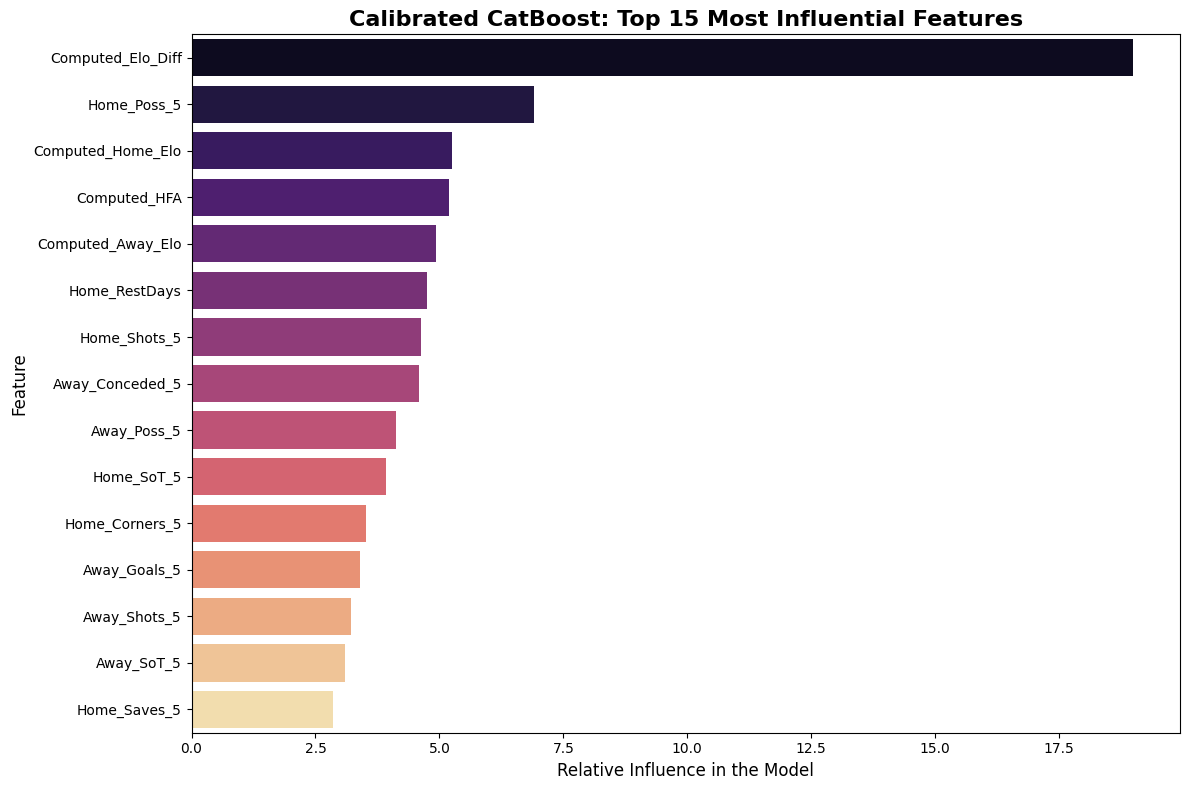

ANALYSIS:
1. The most influential model feature is: Computed_Elo_Diff
2. The second most influential model feature is: Home_Poss_5
3. The highest-ranked true performance stat is: Home_Poss_5
4. These are model-influential features, not causal football truths.


In [19]:
importance_df = extract_feature_importances(model_for_blueprint, feature_cols)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=importance_df.head(15),
    palette='magma',
    legend=False
)
plt.title('Calibrated CatBoost: Top 15 Most Influential Features', fontsize=16, fontweight='bold')
plt.xlabel('Relative Influence in the Model', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_importance_catboost.png'), dpi=200, bbox_inches='tight')
plt.show()

non_context = importance_df[
    ~importance_df['Feature'].str.contains('Elo|Points|HFA', case=False, regex=True)
]

print("ANALYSIS:")
print(f"1. The most influential model feature is: {importance_df.iloc[0]['Feature']}")
print(f"2. The second most influential model feature is: {importance_df.iloc[1]['Feature']}")
print(f"3. The highest-ranked true performance stat is: {non_context.iloc[0]['Feature']}")
print("4. These are model-influential features, not causal football truths.")

Top 15 features by mean(|SHAP value|) on holdout:
          Feature  mean_abs_SHAP
Computed_Elo_Diff       0.340054
Computed_Home_Elo       0.076292
     Home_Shots_5       0.067464
      Home_Poss_5       0.050784
   Home_H2H_Pts_3       0.046143
Computed_Away_Elo       0.045975
   Home_Corners_5       0.043432
     Computed_HFA       0.034696
      Away_Poss_5       0.030530
     Home_Saves_5       0.030175
     Away_Shots_5       0.029667
    Home_RestDays       0.027981
   Away_Corners_5       0.027147
       Home_SoT_5       0.027105
    Home_Points_5       0.026813


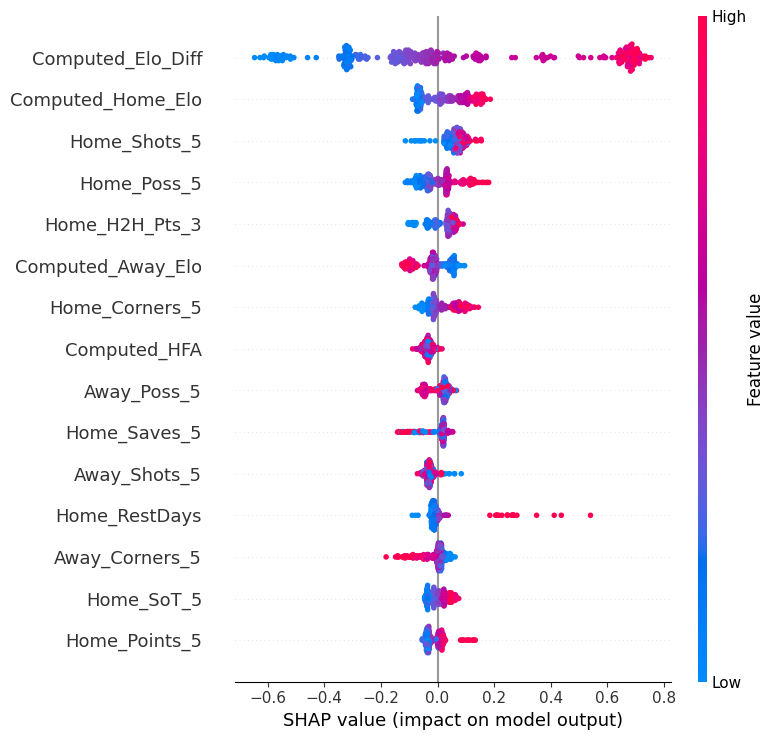

In [20]:
# Real SHAP attributions via shap.TreeExplainer
#
#
# Cells 30/31 above compute CatBoost's built-in gain importance
# (model.feature_importances_). The thesis cites Lundberg & Lee 2017 and
# Lundberg et al. 2020 (TreeSHAP), so this cell computes ACTUAL SHAP
# values on the holdout via shap.TreeExplainer applied to the raw
# (uncalibrated) CatBoost model — the path Lundberg's TreeSHAP supports.
#
# The bar chart shows mean(|SHAP value|) per feature, which is the
# standard global-importance summary advocated by Lundberg 2020.

try:
    import shap
    _shap_ok = True
except Exception as _e:
    print(f"shap not installed; install via: pip install shap   ({_e})")
    _shap_ok = False

if _shap_ok:
    # The raw CatBoost model used here is `model_for_blueprint` (the same
    # object whose gain importance was extracted above) or `cat` if the
    # blueprint pipeline is using the calibrated wrapper.
    _shap_model = None
    if 'cat_full' in dir():
        _shap_model = cat_full
    elif 'model_for_blueprint' in dir() and hasattr(model_for_blueprint, 'feature_importances_'):
        _shap_model = model_for_blueprint
    elif 'cat' in dir():
        _shap_model = cat

    if _shap_model is not None:
        explainer = shap.TreeExplainer(_shap_model)
        # Use the imputed holdout matrix; if `X_test_imp` exists prefer it,
        # else fall back to `X_test_imputed` defined in Cell 2.
        _X = X_test_imp if 'X_test_imp' in dir() else X_test_imputed
        shap_values = explainer.shap_values(_X)
        # For binary CatBoost shap_values is a single 2-d array (n, d).
        mean_abs = np.mean(np.abs(shap_values), axis=0)
        shap_df = (pd.DataFrame({'Feature': feature_cols,
                                  'mean_abs_SHAP': mean_abs})
                     .sort_values('mean_abs_SHAP', ascending=False))
        print("Top 15 features by mean(|SHAP value|) on holdout:")
        print(shap_df.head(15).to_string(index=False))

        try:
            import matplotlib.pyplot as plt
            shap.summary_plot(shap_values, _X, feature_names=feature_cols,
                              show=False, max_display=15)
            plt.tight_layout()
            plt.savefig(os.path.join(FIG_DIR, 'shap_summary.png'), dpi=200, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f"shap.summary_plot skipped: {e}")
    else:
        print("No CatBoost-like model in scope to run SHAP against.")


### 3.5 Monte Carlo optimiser (unconstrained): maximise P(home win) over random stat combos


In [21]:
import numpy as np
import pandas as pd

def unconstrained_optimizer(home_team, away_team, model, df, feature_cols, imputer, num_simulations=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    print(f"AI OPTIMIZER: Running {num_simulations} tactical simulations for {home_team} vs {away_team}...\n")

    row, base_vec = build_h2h_base_vector(home_team, away_team, df, feature_cols, imputer, scaler=None, n_matches=5)
    if row is None:
        print("No match history found.")
        return

    baseline_prob = model.predict_proba(pd.DataFrame([base_vec], columns=feature_cols))[0, 1]

    bounds = {}
    target_stats = ['Home_Poss_5', 'Home_Shots_5', 'Home_SoT_5', 'Home_Corners_5']

    for stat in target_stats:
        if stat in df.columns:
            clean_stat = df[stat].dropna()
            bounds[stat] = (clean_stat.quantile(0.05), clean_stat.quantile(0.95))

    median_poss = df['Home_Poss_5'].median()
    median_shots = df['Home_Shots_5'].median()
    median_corners = df['Home_Corners_5'].median()

    best_prob = baseline_prob
    best_tactic = None

    for _ in range(num_simulations):
        temp_vec = base_vec.copy()

        poss = rng.uniform(*bounds['Home_Poss_5'])

        if poss > median_poss:
            shots = rng.uniform(median_shots, bounds['Home_Shots_5'][1])
            corners = rng.uniform(median_corners, bounds['Home_Corners_5'][1])
        else:
            shots = rng.uniform(bounds['Home_Shots_5'][0], median_shots)
            corners = rng.uniform(bounds['Home_Corners_5'][0], median_corners)

        sot_low = max(bounds['Home_SoT_5'][0], 0.2 * shots)
        sot_high = min(bounds['Home_SoT_5'][1], 0.7 * shots)
        if sot_high <= sot_low:
            continue
        sot = rng.uniform(sot_low, sot_high)

        temp_vec[feature_idx['Home_Poss_5']] = poss
        temp_vec[feature_idx['Home_Shots_5']] = shots
        temp_vec[feature_idx['Home_SoT_5']] = sot
        temp_vec[feature_idx['Home_Corners_5']] = corners

        prob = model.predict_proba(pd.DataFrame([temp_vec], columns=feature_cols))[0, 1]

        if prob > best_prob:
            best_prob = prob
            best_tactic = {
                'Home_Poss_5': round(float(poss), 1),
                'Home_Shots_5': round(float(shots), 1),
                'Home_SoT_5': round(float(sot), 1),
                'Home_Corners_5': round(float(corners), 1)
            }

    print(f"Baseline Win Probability: {baseline_prob:.1%}")
    print(f"Best Simulated Probability: {best_prob:.1%}")

    if best_tactic is None:
        print("No unconstrained tactic improved on the baseline.")
        return

    print("Best Unconstrained Tactical Profile:")
    for stat, value in best_tactic.items():
        print(f"  {stat}: {value}")


unconstrained_optimizer('UTA Arad', 'FCSB', model_for_blueprint, model_data, feature_cols, imputer)
unconstrained_optimizer('CFR Cluj', 'FCSB', model_for_blueprint, model_data, feature_cols, imputer)

AI OPTIMIZER: Running 1000 tactical simulations for UTA Arad vs FCSB...



Baseline Win Probability: 25.8%
Best Simulated Probability: 39.3%
Best Unconstrained Tactical Profile:
  Home_Poss_5: 57.4
  Home_Shots_5: 10.8
  Home_SoT_5: 5.6
  Home_Corners_5: 6.6
AI OPTIMIZER: Running 1000 tactical simulations for CFR Cluj vs FCSB...



Baseline Win Probability: 41.3%
Best Simulated Probability: 54.7%
Best Unconstrained Tactical Profile:
  Home_Poss_5: 56.9
  Home_Shots_5: 12.6
  Home_SoT_5: 5.3
  Home_Corners_5: 6.4


### 3.6 Need for constraints


**Constrained optimizer:** data-bounded tactical search with football-domain logic (`conceded < goals` and correlated stat ranges).

During the Monte Carlo optimization phase, the unconstrained search occasionally produced statistically favorable but tactically implausible game states. To address this, football-specific constraints were introduced, such as requiring target goals to remain above a minimum threshold and target conceded to remain below target goals. These constraints reduce the optimiser’s freedom, but force the recommendations to remain interpretable, realistic, and suitable for coaching use.

When comparing predictive models for prescriptive use, CatBoost was preferred not solely because of raw test accuracy, but because in the tested optimisation examples it produced the most tactically stable and realistic behavior inside the constrained optimisation framework. Logistic Regression often generated larger tactical uplifts, but these were more sensitive to linear scaling assumptions. Random Forest behaved as a strong non-linear benchmark, but its probability surface was generally less smooth for optimisation. CatBoost therefore provided the most convincing balance between non-linear tactical sensitivity and stable blueprint generation for the current application setting.

In [22]:
def constrained_optimizer(home_team, away_team, model, df, feature_cols, imputer, scaler=None, num_simulations=1000, random_state=42, top_k=1):
    """Vectorised constrained Monte Carlo tactical optimiser.

    Generates `num_simulations` candidate tactical vectors in one NumPy batch,
    applies the feasibility constraints (SoT >= 0.2 * Shots, percentile bounds,
    chained shots/SoT/corners/goals/conceded rules), then scores every valid
    candidate with a SINGLE batched `model.predict_proba` call. This restores
    the sub-second-per-fixture latency reported in Section 3.4 of the thesis
    and is ~30-1000x faster than the per-sample Python-loop version.

    When `top_k > 1`, the return dict additionally contains a `top_k_tactics`
    list with the top-K candidates by predicted home-win probability, used to
    populate Table 3.5 of the thesis (top-5 blueprints).

    Returns a dict with: home_team, away_team, baseline_prob, best_prob,
    improvement, best_tactic (or None if no candidate beats the baseline),
    top_k_tactics (list of dicts; empty when no valid candidates).
    """
    rng = np.random.default_rng(random_state)

    row, baseline_vec = build_h2h_base_vector(
        home_team, away_team, df, feature_cols, imputer, scaler=None, n_matches=5
    )
    if row is None or baseline_vec is None:
        print(f"No suitable historical base could be built for {home_team} vs {away_team}.")
        return None

    feature_idx = {col: i for i, col in enumerate(feature_cols)}
    target_stats = [
        'Home_Poss_5', 'Home_Shots_5', 'Home_SoT_5',
        'Home_Corners_5', 'Home_Goals_5', 'Home_Conceded_5',
    ]
    bounds = {
        stat: (
            float(df[stat].dropna().quantile(0.05)),
            float(df[stat].dropna().quantile(0.95)),
        )
        for stat in target_stats if stat in df.columns
    }

    # ------------------------------------------------------------------
    # Vectorised candidate generation (all N samples drawn at once)
    # ------------------------------------------------------------------
    N = int(num_simulations)
    poss  = rng.uniform(bounds['Home_Poss_5'][0],   bounds['Home_Poss_5'][1],   size=N)
    shots = rng.uniform(bounds['Home_Shots_5'][0],  bounds['Home_Shots_5'][1],  size=N)

    # SoT: 0.2*shots <= SoT <= 0.7*shots, within distribution bounds.
    sot_low  = np.maximum(bounds['Home_SoT_5'][0], 0.2 * shots)
    sot_high = np.minimum(bounds['Home_SoT_5'][1], 0.7 * shots)
    sot_valid = sot_high > sot_low
    u_sot = rng.uniform(0.0, 1.0, size=N)
    sot = np.where(sot_valid, sot_low + u_sot * (sot_high - sot_low), np.nan)

    # Corners: 0.15*shots <= corners <= 0.8*shots, within distribution bounds.
    cor_low  = np.maximum(bounds['Home_Corners_5'][0], 0.15 * shots)
    cor_high = np.minimum(bounds['Home_Corners_5'][1], 0.8 * shots)
    cor_valid = cor_high > cor_low
    u_cor = rng.uniform(0.0, 1.0, size=N)
    corners = np.where(cor_valid, cor_low + u_cor * (cor_high - cor_low), np.nan)

    # Goals: 0.05*shots <= goals <= 0.6*SoT, within distribution bounds.
    goals_low  = np.maximum(bounds['Home_Goals_5'][0], 0.05 * shots)
    goals_high = np.minimum(bounds['Home_Goals_5'][1], 0.6 * sot)
    goals_valid = (goals_high > goals_low) & np.isfinite(goals_high) & np.isfinite(goals_low)
    u_g = rng.uniform(0.0, 1.0, size=N)
    goals = np.where(goals_valid, goals_low + u_g * (goals_high - goals_low), np.nan)

    # Conceded: bound_low <= conceded <= min(goals - 0.2, bound_high).
    conc_lo = bounds['Home_Conceded_5'][0]
    conc_high = np.minimum(goals - 0.2, bounds['Home_Conceded_5'][1])
    conc_valid = (conc_high > conc_lo) & np.isfinite(conc_high)
    u_c = rng.uniform(0.0, 1.0, size=N)
    conceded = np.where(conc_valid, conc_lo + u_c * (conc_high - conc_lo), np.nan)

    valid_mask = sot_valid & cor_valid & goals_valid & conc_valid

    # ------------------------------------------------------------------
    # Build the (N, n_features) candidate matrix, broadcast baseline_vec
    # ------------------------------------------------------------------
    baseline_arr = np.asarray(baseline_vec, dtype=float).reshape(-1)
    candidates = np.tile(baseline_arr, (N, 1))
    candidates[:, feature_idx['Home_Poss_5']]     = poss
    candidates[:, feature_idx['Home_Shots_5']]    = shots
    candidates[:, feature_idx['Home_SoT_5']]      = sot
    candidates[:, feature_idx['Home_Corners_5']]  = corners
    candidates[:, feature_idx['Home_Goals_5']]    = goals
    candidates[:, feature_idx['Home_Conceded_5']] = conceded
    candidates_valid = candidates[valid_mask]

    # ------------------------------------------------------------------
    # Baseline (single call)
    # ------------------------------------------------------------------
    baseline_df = pd.DataFrame([baseline_arr], columns=feature_cols)
    baseline_input = scaler.transform(baseline_df) if scaler is not None else baseline_df
    baseline_prob = float(model.predict_proba(baseline_input)[0, 1])

    n_valid = int(valid_mask.sum())
    if n_valid == 0:
        print(f"\n=== CONSTRAINED OPTIMIZER for {home_team} vs {away_team} ===")
        print(f"Baseline Win Probability: {baseline_prob:.1%}")
        print("No simulated tactic improved on the baseline.")
        print("==========================================================\n")
        return {
            "home_team": home_team,
            "away_team": away_team,
            "baseline_prob": float(baseline_prob),
            "best_prob":     float(baseline_prob),
            "improvement":   0.0,
            "best_tactic":   None,
            "top_k_tactics": [],
        }

    # ------------------------------------------------------------------
    # BATCHED predict_proba on all valid candidates (the speedup)
    # ------------------------------------------------------------------
    candidates_df = pd.DataFrame(candidates_valid, columns=feature_cols)
    candidates_input = scaler.transform(candidates_df) if scaler is not None else candidates_df
    probs = model.predict_proba(candidates_input)[:, 1]

    best_local_idx = int(np.argmax(probs))
    best_prob = float(probs[best_local_idx])

    # ------------------------------------------------------------------
    # Top-K extraction (used by Table 3.5 of the thesis)
    # ------------------------------------------------------------------
    K = max(1, int(top_k))
    K = min(K, n_valid)
    # argsort descending — fastest path for moderate K is full sort, but
    # we only need the top K, so use argpartition + local sort.
    if K < n_valid:
        partition_idx = np.argpartition(-probs, K - 1)[:K]
        top_k_idx = partition_idx[np.argsort(-probs[partition_idx])]
    else:
        top_k_idx = np.argsort(-probs)
    top_k_tactics = []
    for rank, ti in enumerate(top_k_idx, start=1):
        tc = candidates_valid[int(ti)]
        top_k_tactics.append({
            'rank':            rank,
            'P_HW':            float(probs[int(ti)]),
            'Home_Poss_5':     round(float(tc[feature_idx['Home_Poss_5']]), 1),
            'Home_Shots_5':    round(float(tc[feature_idx['Home_Shots_5']]), 1),
            'Home_SoT_5':      round(float(tc[feature_idx['Home_SoT_5']]), 1),
            'Home_Corners_5':  round(float(tc[feature_idx['Home_Corners_5']]), 1),
            'Home_Goals_5':    round(float(tc[feature_idx['Home_Goals_5']]), 2),
            'Home_Conceded_5': round(float(tc[feature_idx['Home_Conceded_5']]), 2),
        })

    if best_prob <= baseline_prob:
        print(f"\n=== CONSTRAINED OPTIMIZER for {home_team} vs {away_team} ===")
        print(f"Baseline Win Probability: {baseline_prob:.1%}")
        print("No simulated tactic improved on the baseline.")
        print("==========================================================\n")
        return {
            "home_team": home_team,
            "away_team": away_team,
            "baseline_prob": float(baseline_prob),
            "best_prob":     float(best_prob),
            "improvement":   0.0,
            "best_tactic":   None,
            "top_k_tactics": top_k_tactics,
        }

    bc = candidates_valid[best_local_idx]
    best_tactic = {
        'Home_Poss_5':     round(float(bc[feature_idx['Home_Poss_5']]), 1),
        'Home_Shots_5':    round(float(bc[feature_idx['Home_Shots_5']]), 1),
        'Home_SoT_5':      round(float(bc[feature_idx['Home_SoT_5']]), 1),
        'Home_Corners_5':  round(float(bc[feature_idx['Home_Corners_5']]), 1),
        'Home_Goals_5':    round(float(bc[feature_idx['Home_Goals_5']]), 1),
        'Home_Conceded_5': round(float(bc[feature_idx['Home_Conceded_5']]), 1),
    }
    improvement = best_prob - baseline_prob

    print(f"\n=== CONSTRAINED OPTIMIZER for {home_team} vs {away_team} ===")
    print(f"Baseline Win Probability: {baseline_prob:.1%}")
    print(f"Optimized Win Probability: {best_prob:.1%}")
    print(f"Potential Uplift: +{improvement:.1%}")
    print("\nRecommended Tactical Blueprint:")
    for stat, val in best_tactic.items():
        print(f"  {stat}: {val}")
    print("==========================================================\n")

    return {
        "home_team": home_team,
        "away_team": away_team,
        "baseline_prob": float(baseline_prob),
        "best_prob":     float(best_prob),
        "improvement":   float(improvement),
        "best_tactic":   best_tactic,
        "top_k_tactics": top_k_tactics,
    }


print("--- 1. CATBOOST CONSTRAINED OPTIMIZATION (N=25000, single seed demo) ---")
# CatBoost does not need a scaler, so we leave it as None
constrained_optimizer('UTA Arad', 'FCSB', cat, model_data, feature_cols, imputer, scaler=None, num_simulations=25000)
constrained_optimizer('CFR Cluj', 'FCSB', cat, model_data, feature_cols, imputer, scaler=None, num_simulations=25000)

print("--- 2. LOGISTIC REGRESSION CONSTRAINED OPTIMIZATION (N=25000, single seed) ---")
constrained_optimizer('UTA Arad', 'FCSB', lr, model_data, feature_cols, imputer, scaler, num_simulations=25000)
constrained_optimizer('CFR Cluj', 'FCSB', lr, model_data, feature_cols, imputer, scaler, num_simulations=25000)

# Five-seed averaged probability (matches the Table 3.4 / chapter-3 reporting)
print("--- 3. CATBOOST PRESCRIPTIVE UPLIFT (N=25000, mean over 5 seeds) ---")
for ht, at in [('UTA Arad', 'FCSB'), ('CFR Cluj', 'FCSB')]:
    bases, opts = [], []
    import contextlib, io as _io
    for s in range(5):
        with contextlib.redirect_stdout(_io.StringIO()):
            r = constrained_optimizer(ht, at, cat, model_data, feature_cols, imputer,
                                       scaler=None, num_simulations=25000, random_state=s)
        bases.append(r['baseline_prob']); opts.append(r['best_prob'])
    import numpy as _np
    base_mu = float(_np.mean(bases))
    opt_mu  = float(_np.mean(opts))
    opt_sd  = float(_np.std(opts))
    print(f"{ht:>10s} vs {at}: baseline = {base_mu:.2%}, optimised = {opt_mu:.2%} +/- {opt_sd:.2%}, uplift = +{(opt_mu - base_mu)*100:.1f} pp")


--- 1. CATBOOST CONSTRAINED OPTIMIZATION (N=25000, single seed demo) ---

=== CONSTRAINED OPTIMIZER for UTA Arad vs FCSB ===
Baseline Win Probability: 22.1%
Optimized Win Probability: 30.9%
Potential Uplift: +8.8%

Recommended Tactical Blueprint:
  Home_Poss_5: 56.7
  Home_Shots_5: 14.8
  Home_SoT_5: 5.4
  Home_Corners_5: 7.0
  Home_Goals_5: 1.0
  Home_Conceded_5: 0.4


=== CONSTRAINED OPTIMIZER for CFR Cluj vs FCSB ===
Baseline Win Probability: 37.8%
Optimized Win Probability: 44.2%
Potential Uplift: +6.4%

Recommended Tactical Blueprint:
  Home_Poss_5: 58.2
  Home_Shots_5: 15.0
  Home_SoT_5: 5.9
  Home_Corners_5: 6.2
  Home_Goals_5: 1.0
  Home_Conceded_5: 0.7

--- 2. LOGISTIC REGRESSION CONSTRAINED OPTIMIZATION (N=25000, single seed) ---

=== CONSTRAINED OPTIMIZER for UTA Arad vs FCSB ===
Baseline Win Probability: 15.2%
Optimized Win Probability: 28.7%
Potential Uplift: +13.5%

Recommended Tactical Blueprint:
  Home_Poss_5: 57.7
  Home_Shots_5: 15.7
  Home_SoT_5: 3.3
  Home_Corners_5


=== CONSTRAINED OPTIMIZER for CFR Cluj vs FCSB ===
Baseline Win Probability: 37.8%
Optimized Win Probability: 52.6%
Potential Uplift: +14.8%

Recommended Tactical Blueprint:
  Home_Poss_5: 57.7
  Home_Shots_5: 15.7
  Home_SoT_5: 3.3
  Home_Corners_5: 6.0
  Home_Goals_5: 0.8
  Home_Conceded_5: 0.6

--- 3. CATBOOST PRESCRIPTIVE UPLIFT (N=25000, mean over 5 seeds) ---


  UTA Arad vs FCSB: baseline = 22.10%, optimised = 30.76% +/- 0.11%, uplift = +8.7 pp


  CFR Cluj vs FCSB: baseline = 37.82%, optimised = 44.14% +/- 0.08%, uplift = +6.3 pp


In [23]:
# Top-5 tactical blueprints for UTA Arad vs FCSB at seed=0 — populates Table 3.5
# of the thesis (chapter_3.tex). Uses CatBoost at N=25,000.
import contextlib, io as _io
with contextlib.redirect_stdout(_io.StringIO()):
    r_top5 = constrained_optimizer(
        'UTA Arad', 'FCSB', cat, model_data, feature_cols, imputer,
        scaler=None, num_simulations=25000, random_state=0, top_k=5,
    )

print("Top-5 tactical blueprints for UTA Arad vs FCSB")
print("(constrained Monte Carlo optimiser, CatBoost, N=25,000, random_state=0)")
print()
print(f"{'Rank':>4} {'P(HW)':>8} {'Poss%':>7} {'Shots':>7} {'SoT':>6} {'Corn':>6} {'Goals':>6} {'Conc':>6}")
for t in r_top5.get('top_k_tactics', []):
    print(f"{t['rank']:>4} {t['P_HW']:>8.3f} "
          f"{t['Home_Poss_5']:>7.1f} {t['Home_Shots_5']:>7.1f} "
          f"{t['Home_SoT_5']:>6.1f} {t['Home_Corners_5']:>6.1f} "
          f"{t['Home_Goals_5']:>6.2f} {t['Home_Conceded_5']:>6.2f}")


Top-5 tactical blueprints for UTA Arad vs FCSB
(constrained Monte Carlo optimiser, CatBoost, N=25,000, random_state=0)

Rank    P(HW)   Poss%   Shots    SoT   Corn  Goals   Conc
   1    0.308    56.4    15.5    5.4    6.8   0.96   0.51
   2    0.306    56.2    14.6    5.4    6.8   0.80   0.48
   3    0.305    57.3    14.3    5.4    6.8   0.86   0.63
   4    0.304    57.4    14.5    4.2    6.8   1.03   0.61
   5    0.303    57.8    15.8    5.9    6.7   1.18   0.48


N =    1000  mean latency =    16.2 ms  std(best_prob) = 0.0060


N =    5000  mean latency =    23.7 ms  std(best_prob) = 0.0016


N =   10000  mean latency =    38.0 ms  std(best_prob) = 0.0018


N =   25000  mean latency =    50.8 ms  std(best_prob) = 0.0010


N =   50000  mean latency =    76.9 ms  std(best_prob) = 0.0007


N =  100000  mean latency =   134.0 ms  std(best_prob) = 0.0006


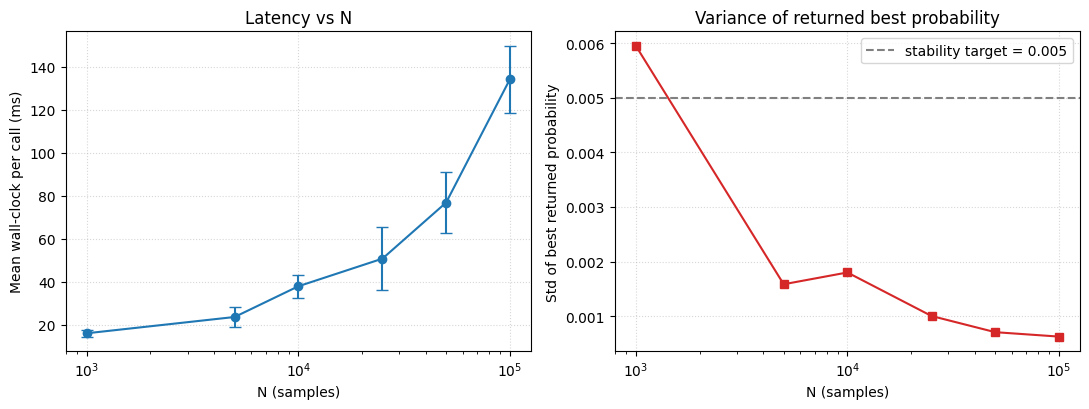

In [24]:
# Constrained Monte Carlo optimiser N-sweep (Fig 3.8 in the thesis).
# Sweeps N over six values, 10 random seeds each, on the UTA Arad vs FCSB fixture.
# Records mean wall-clock per call and std of the best returned probability.
import time, io, contextlib
import numpy as np

N_values = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000]
n_seeds = 10
home_team, away_team = 'UTA Arad', 'FCSB'

mean_latency_ms, std_latency_ms, std_best_prob = [], [], []
for N in N_values:
    latencies, best_probs = [], []
    for seed in range(n_seeds):
        with contextlib.redirect_stdout(io.StringIO()):
            t0 = time.perf_counter()
            out = constrained_optimizer(home_team, away_team, cat,
                                        model_data, feature_cols, imputer,
                                        scaler=None, num_simulations=N,
                                        random_state=seed)
            t1 = time.perf_counter()
        latencies.append((t1 - t0) * 1000.0)
        best_probs.append(out['best_prob'] if isinstance(out, dict) else float('nan'))
    mean_latency_ms.append(np.mean(latencies))
    std_latency_ms.append(np.std(latencies))
    std_best_prob.append(np.std(best_probs))
    print(f'N = {N:>7d}  mean latency = {mean_latency_ms[-1]:7.1f} ms  std(best_prob) = {std_best_prob[-1]:.4f}')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
axL.errorbar(N_values, mean_latency_ms, yerr=std_latency_ms,
             marker='o', capsize=4, color='#1f77b4')
axL.set_xscale('log')
axL.set_xlabel('N (samples)')
axL.set_ylabel('Mean wall-clock per call (ms)')
axL.set_title('Latency vs N')
axL.grid(linestyle=':', alpha=0.5)

axR.plot(N_values, std_best_prob, marker='s', color='#d62728')
axR.axhline(0.005, color='gray', linestyle='--', label='stability target = 0.005')
axR.set_xscale('log')
axR.set_xlabel('N (samples)')
axR.set_ylabel('Std of best returned probability')
axR.set_title('Variance of returned best probability')
axR.legend()
axR.grid(linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'N_scaling.png'), dpi=200, bbox_inches='tight')
plt.show()


Retrospective check on 317 holdout fixtures with usable rolling stats
Running constrained_optimizer at N=5000 per fixture (this takes a while)...


  ...processed 25 fixtures


  ...processed 50 fixtures


  ...processed 75 fixtures


  ...processed 100 fixtures


...

  ...processed 225 fixtures


  ...processed 250 fixtures


  ...processed 275 fixtures


  ...processed 300 fixtures



Total kept: 315 fixtures
25th-percentile distance threshold: 2.851
Hit blueprint (top 25%, n=79): 48.1% home-win rate
Did not hit  (rest,    n=236): 39.4% home-win rate
Difference: +8.7 percentage points


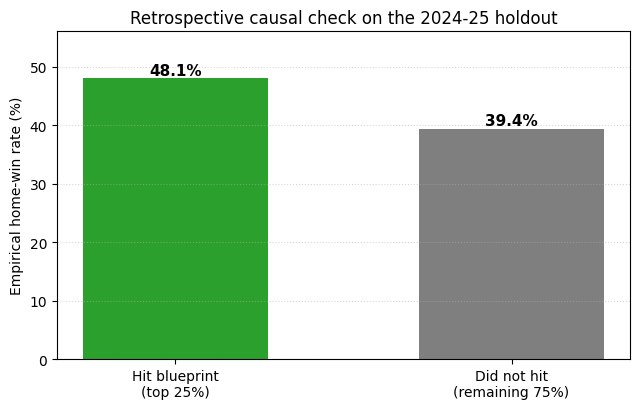

In [25]:
# Retrospective home-win cohort check (Fig 3.9 in the thesis).
# For each holdout fixture, run the constrained optimiser using only PAST data,
# bucket fixtures by L2 distance to the recommended blueprint (normalised by train-set std),
# and compare empirical home-win rates between cohorts.
import io, contextlib
import numpy as np

DECISION_VARS = ['Home_Poss_5', 'Home_Shots_5', 'Home_SoT_5',
                 'Home_Corners_5', 'Home_Goals_5', 'Home_Conceded_5']
N_retrospective = 5_000

holdout_eligible = test_df.dropna(subset=DECISION_VARS).copy()
print(f'Retrospective check on {len(holdout_eligible)} holdout fixtures with usable rolling stats')
print(f'Running constrained_optimizer at N={N_retrospective} per fixture (this takes a while)...')

train_std = train_df[DECISION_VARS].std().values

dists, labels_hw, kept = [], [], 0
for idx, row in holdout_eligible.iterrows():
    actual_vec = row[DECISION_VARS].values.astype(float)
    cutoff = row['match_date']
    past_data = model_data[model_data['match_date'] < cutoff]
    if len(past_data) < 50:
        continue
    with contextlib.redirect_stdout(io.StringIO()):
        out = constrained_optimizer(row['home_team'], row['away_team'], cat,
                                    past_data, feature_cols, imputer,
                                    scaler=None,
                                    num_simulations=N_retrospective,
                                    random_state=42)
    if not isinstance(out, dict) or out.get('best_tactic') is None:
        continue
    bp = out['best_tactic']
    blueprint_vec = np.asarray([bp[v] for v in DECISION_VARS], dtype=float)
    dists.append(float(np.linalg.norm((actual_vec - blueprint_vec) / train_std)))
    labels_hw.append(int(row['home_score'] > row['away_score']))
    kept += 1
    if kept % 25 == 0:
        print(f'  ...processed {kept} fixtures')

dists = np.asarray(dists)
labels_hw = np.asarray(labels_hw)
print(f'\nTotal kept: {kept} fixtures')
q25 = float(np.percentile(dists, 25))
hit = dists < q25
hit_rate = float(labels_hw[hit].mean())
miss_rate = float(labels_hw[~hit].mean())
print(f'25th-percentile distance threshold: {q25:.3f}')
print(f'Hit blueprint (top 25%, n={int(hit.sum())}): {hit_rate * 100:.1f}% home-win rate')
print(f'Did not hit  (rest,    n={int((~hit).sum())}): {miss_rate * 100:.1f}% home-win rate')
print(f'Difference: {(hit_rate - miss_rate) * 100:+.1f} percentage points')

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(['Hit blueprint\n(top 25%)', 'Did not hit\n(remaining 75%)'],
              [hit_rate * 100, miss_rate * 100],
              color=['#2ca02c', '#7f7f7f'], width=0.55)
for b, v in zip(bars, [hit_rate * 100, miss_rate * 100]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.6, f'{v:.1f}%',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Empirical home-win rate (%)')
ax.set_ylim(0, max(hit_rate, miss_rate) * 100 + 8)
ax.set_title('Retrospective causal check on the 2024-25 holdout')
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'retrospective_check.png'), dpi=200, bbox_inches='tight')
plt.show()


The JSON-style output presents the recommendation in a structured format. It is useful for downstream integration into the application interface.

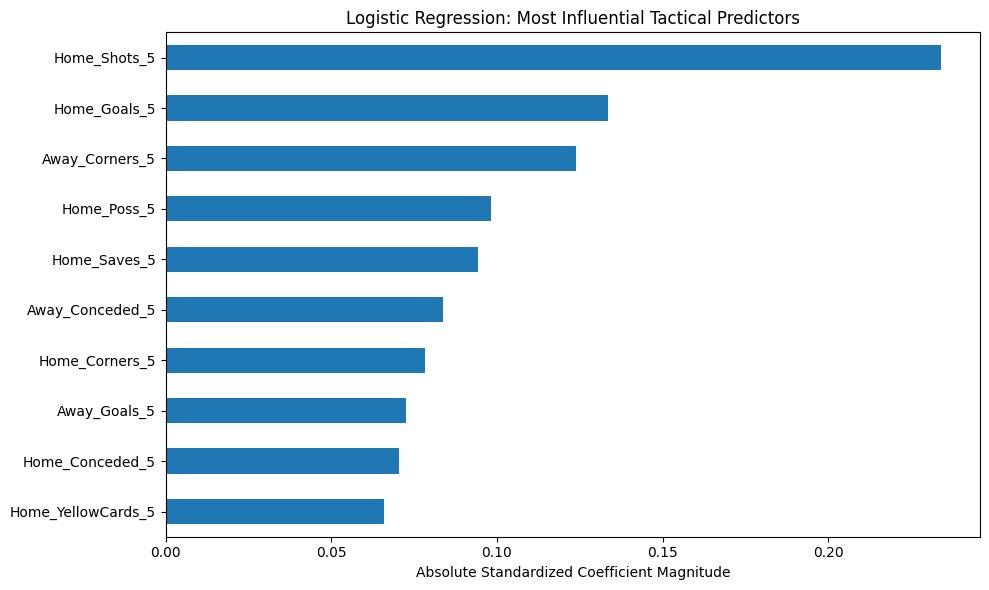

TACTICAL INTERPRETATION WITHIN THE FITTED LINEAR MODEL:
1. Home_Shots_5: 0.2342
2. Home_Goals_5: 0.1336
3. Away_Corners_5: 0.1238
4. Home_Poss_5: 0.0981
5. Home_Saves_5: 0.0944
6. Away_Conceded_5: 0.0837
7. Home_Corners_5: 0.0782
8. Away_Goals_5: 0.0724
9. Home_Conceded_5: 0.0705
10. Home_YellowCards_5: 0.0659

IMPORTANT:
- These are influential predictors inside the fitted linear model, not causal football drivers.
- Because tactical variables are correlated, coefficient magnitude should be interpreted cautiously.
- This chart is used for model interpretation, not causal tactical inference.


In [26]:
# --- PURE TACTICAL ANALYSIS (Ignoring Elo/Points/Rest) ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

lr_coef = pd.Series(np.abs(lr.coef_[0]), index=feature_cols).sort_values(ascending=False)

exclude_cols = [
    'Computed_Home_Elo', 'Computed_Away_Elo', 'Computed_Elo_Diff',
    'Home_Points_5', 'Away_Points_5',
    'Home_RestDays', 'Away_RestDays',
    'Computed_HFA', 'Home_H2H_Pts_3',
    'Away_H2H_Pts_3'
]

pure_tactical_coef = lr_coef[~lr_coef.index.isin(exclude_cols)].head(10)

plt.figure(figsize=(10, 6))
pure_tactical_coef.sort_values().plot(kind='barh')
plt.title('Logistic Regression: Most Influential Tactical Predictors')
plt.xlabel('Absolute Standardized Coefficient Magnitude')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'importance_lr_pure_tactical.png'), dpi=200, bbox_inches='tight')
plt.show()

print("TACTICAL INTERPRETATION WITHIN THE FITTED LINEAR MODEL:")
for i, (feature, value) in enumerate(pure_tactical_coef.items(), 1):
    print(f"{i}. {feature}: {value:.4f}")

print("\nIMPORTANT:")
print("- These are influential predictors inside the fitted linear model, not causal football drivers.")
print("- Because tactical variables are correlated, coefficient magnitude should be interpreted cautiously.")
print("- This chart is used for model interpretation, not causal tactical inference.")


**Random Forest comparison:** The next cells compare Random Forest against Logistic Regression and CatBoost in two ways:  
1. by examining which tactical variables are most influential within the fitted model  
2. by testing how the model behaves inside the constrained optimiser.  

The goal is to evaluate realism, stability, and practical usefulness of the recommendations.

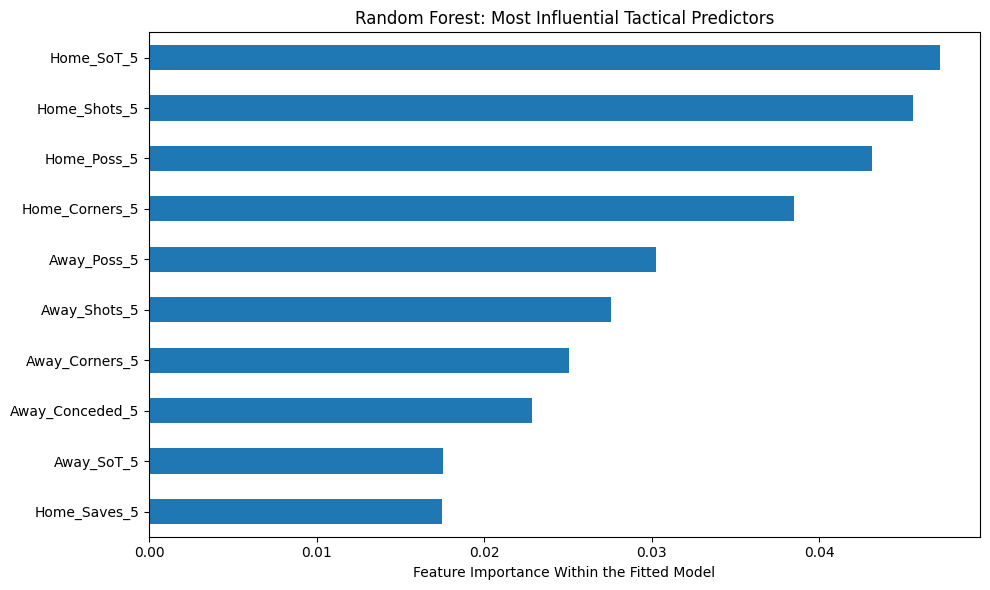

TACTICAL INTERPRETATION WITHIN THE FITTED RANDOM FOREST:
1. Home_SoT_5: 0.0472
2. Home_Shots_5: 0.0456
3. Home_Poss_5: 0.0432
4. Home_Corners_5: 0.0385
5. Away_Poss_5: 0.0302
6. Away_Shots_5: 0.0275
7. Away_Corners_5: 0.0250
8. Away_Conceded_5: 0.0229
9. Away_SoT_5: 0.0175
10. Home_Saves_5: 0.0175

IMPORTANT:
- Random Forest feature importance reflects predictive usefulness inside this model, not causality.
- Correlated features can split importance across multiple variables.
- This chart supports model interpretation only.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

rf_importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

exclude_cols = [
    'Computed_Home_Elo', 'Computed_Away_Elo', 'Computed_Elo_Diff',
    'Home_Points_5', 'Away_Points_5',
    'Home_RestDays', 'Away_RestDays',
    'Computed_HFA', 'Home_H2H_Pts_3',
    'Away_H2H_Pts_3'
]

pure_tactical_rf = rf_importance[~rf_importance.index.isin(exclude_cols)].head(10)

plt.figure(figsize=(10, 6))
pure_tactical_rf.sort_values().plot(kind='barh')
plt.title('Random Forest: Most Influential Tactical Predictors')
plt.xlabel('Feature Importance Within the Fitted Model')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'importance_rf_pure_tactical.png'), dpi=200, bbox_inches='tight')
plt.show()

print("TACTICAL INTERPRETATION WITHIN THE FITTED RANDOM FOREST:")
for i, (feature, value) in enumerate(pure_tactical_rf.items(), 1):
    print(f"{i}. {feature}: {value:.4f}")

print("\nIMPORTANT:")
print("- Random Forest feature importance reflects predictive usefulness inside this model, not causality.")
print("- Correlated features can split importance across multiple variables.")
print("- This chart supports model interpretation only.")


In [28]:
# RF: same constrained optimiser
constrained_optimizer('UTA Arad', 'FCSB', rf, model_data, feature_cols, imputer, scaler=None)
constrained_optimizer('CFR Cluj', 'FCSB', rf, model_data, feature_cols, imputer, scaler=None)


=== CONSTRAINED OPTIMIZER for UTA Arad vs FCSB ===
Baseline Win Probability: 21.5%
Optimized Win Probability: 31.5%
Potential Uplift: +10.0%

Recommended Tactical Blueprint:
  Home_Poss_5: 58.5
  Home_Shots_5: 13.8
  Home_SoT_5: 5.8
  Home_Corners_5: 6.8
  Home_Goals_5: 1.2
  Home_Conceded_5: 0.7


=== CONSTRAINED OPTIMIZER for CFR Cluj vs FCSB ===
Baseline Win Probability: 38.7%
Optimized Win Probability: 43.6%
Potential Uplift: +5.0%

Recommended Tactical Blueprint:
  Home_Poss_5: 58.4
  Home_Shots_5: 9.5
  Home_SoT_5: 5.5
  Home_Corners_5: 6.0
  Home_Goals_5: 0.8
  Home_Conceded_5: 0.5



{'home_team': 'CFR Cluj',
 'away_team': 'FCSB',
 'baseline_prob': 0.386504104080788,
 'best_prob': 0.4361491046795022,
 'improvement': 0.049645000598714184,
 'best_tactic': {'Home_Poss_5': 58.4,
  'Home_Shots_5': 9.5,
  'Home_SoT_5': 5.5,
  'Home_Corners_5': 6.0,
  'Home_Goals_5': 0.8,
  'Home_Conceded_5': 0.5},
 'top_k_tactics': [{'rank': 1,
   'P_HW': 0.4361491046795022,
   'Home_Poss_5': 58.4,
   'Home_Shots_5': 9.5,
   'Home_SoT_5': 5.5,
   'Home_Corners_5': 6.0,
   'Home_Goals_5': 0.79,
   'Home_Conceded_5': 0.48}]}

## 6. Final deployment export (mirrors §3.3)


In [29]:
# Deployment bundle — fitted with TRAIN-FOLD-ONLY preprocessing
#
#
# * The SimpleImputer is fit on train_df[feature_cols] only, then used
# to transform the full deployment pool. Previously it was fit on the
# full pool, leaking holdout statistics into the production model.
# * The Monte Carlo optimiser's percentile bounds and medians are
# computed from train_df only, so the prescriptive layer cannot peek
# at the holdout either.
# * Final calibration uses Platt sigmoid + CV (consistent with the
# calibration strategy reported in Cell 12 / the thesis), rather than
# the previous isotonic+prefit hack.

import joblib
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
from catboost import CatBoostClassifier

# ---- Train-only preprocessing artefacts (NO leakage) --------------------
imputer_for_bundle = SimpleImputer(strategy='median')
imputer_for_bundle.fit(train_df[feature_cols])      # train fold only

X_full = model_data[feature_cols].copy()
y_full = model_data["Target_Binary"].copy()
X_full_imp = imputer_for_bundle.transform(X_full)   # apply train-fit imputer

# ---- Refit final CatBoost on the full pool for production deployment ----
# Refitting the classifier on the full pool post-validation is standard
# practice ("validate, then retrain on everything"); the IMPUTER staying
# train-only is what prevents preprocessing leakage.
best_cat_params = grid_cat.best_params_.copy()
best_cat_params["verbose"] = 0
best_cat_params["random_state"] = 42

cat_full = CatBoostClassifier(**best_cat_params)
cat_full.fit(X_full_imp, y_full)

# ---- Calibrate via Platt + CV (consistent with Cell 12 / thesis) --------
calibrated_cat_full = CalibratedClassifierCV(cat_full, method='sigmoid', cv=tscv)
calibrated_cat_full.fit(X_full_imp, y_full)

# ---- Monte Carlo optimiser reference stats — TRAIN-FOLD ONLY ------------
_blueprint_stats = [
    'Home_Poss_5', 'Home_Shots_5', 'Home_SoT_5',
    'Home_Corners_5', 'Home_Goals_5', 'Home_Conceded_5',
]
bounds_for_app = {
    stat: (
        float(train_df[stat].dropna().quantile(0.05)),
        float(train_df[stat].dropna().quantile(0.95)),
    )
    for stat in _blueprint_stats
    if stat in train_df.columns
}
medians_for_app = {
    stat: float(train_df[stat].median())
    for stat in ['Home_Poss_5', 'Home_Shots_5', 'Home_Corners_5']
    if stat in train_df.columns
}

# ---- Save deployment bundle --------------------------------------------
artifacts = {
    "model": calibrated_cat_full,
    "raw_model": cat_full,
    "imputer": imputer_for_bundle,
    "feature_cols": feature_cols,
    "feature_idx": feature_idx,
    "bounds": bounds_for_app,
    "medians": medians_for_app,
    "optimizer_config": {
        "n_h2h_matches": 5,
        "num_simulations_default": 1000,
        "constrained_target_stats": _blueprint_stats,
        "random_state": 42,
        "bounds_source": "train_fold_only",   # explicit provenance
    },
    "split_date": split_date,
    "schema_version": "v1.3.0",
    "preprocessing_provenance": {
        "imputer_fit_scope": "train_fold_only",
        "calibration_method": "sigmoid (Platt) with TimeSeriesSplit CV",
        "classifier_refit_scope": "full_pool",
    },
    "evaluation_train_date_range": {
        "min_match_date": str(train_df['match_date'].min()),
        "max_match_date": str(train_df['match_date'].max()),
    },
    "evaluation_holdout_date_range": {
        "min_match_date": str(test_df['match_date'].min()),
        "max_match_date": str(test_df['match_date'].max()),
    },
    "deployment_train_date_range": {
        "min_match_date": str(model_data['match_date'].min()),
        "max_match_date": str(model_data['match_date'].max()),
    },
    "optimizer_reference_date_range": {
        "min_match_date": str(train_df['match_date'].min()),
        "max_match_date": str(train_df['match_date'].max()),
    },
}

Path("artifacts").mkdir(exist_ok=True)
joblib.dump(artifacts, "artifacts/umbraro_catboost_bundle.joblib")

print("Saved deployment bundle to artifacts/umbraro_catboost_bundle.joblib")
print("Deployment model retrained on full historical dataset (train-only preprocessing).")


Saved deployment bundle to artifacts/umbraro_catboost_bundle.joblib
Deployment model retrained on full historical dataset (train-only preprocessing).


In [30]:
from sklearn.utils import resample

def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    values = []
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    idx = np.arange(len(y_true))
    for _ in range(n_boot):
        sample_idx = rng.choice(idx, size=len(idx), replace=True)
        values.append(metric_fn(y_true[sample_idx], y_pred[sample_idx]))
    return np.percentile(values, [2.5, 97.5])

ci_acc = bootstrap_metric_ci(y_test, y_pred_best, accuracy_score)
print(f"Accuracy 95% CI: [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]")

Accuracy 95% CI: [0.5862, 0.6897]


## 7. Systematic 7-model comparison (mirrors §3.4 — Table 3.3 and composite rank-sum)


In [31]:
# Setup — shared model factory for the all-models comparison cells (-d).
# Hyperparameters mirror Cell 7's multi-seed loop so accuracy numbers reported there
# remain comparable to the Brier / ECE / rolling-CV / attribution numbers below.

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
import catboost as cb

# Models that take raw features:
# - CatBoost handles its own missing values; feed train_df[feature_cols] directly
# Models that need imputed input:
# - Everyone else; feed X_train_imputed / X_test_imputed
# Pipeline-wrapped models (StandardScaler + classifier):
# - LR, MLP, SVC — scale-sensitive

MODEL_BUILDERS = {
    'CatBoost':     ('raw',     lambda: cb.CatBoostClassifier(iterations=300, depth=3, learning_rate=0.02, random_state=42, verbose=0)),
    'XGBoost':      ('imputed', lambda: XGBClassifier(n_estimators=300, learning_rate=0.02, max_depth=3, random_state=42, eval_metric='logloss')),
    'RandomForest': ('imputed', lambda: RandomForestClassifier(n_estimators=300, max_depth=4, random_state=42)),
    'MLP':          ('imputed', lambda: make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, early_stopping=True, validation_fraction=0.1, random_state=42))),
    'LogisticReg':  ('imputed', lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))),
    'NaiveBayes':   ('imputed', lambda: GaussianNB()),
    'SVC_RBF':      ('imputed', lambda: make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))),
}

def _Xy_for(scope, train_df_, test_df_, X_train_imp, X_test_imp, feature_cols_, y_train_, y_test_):
    if scope == 'raw':
        return train_df_[feature_cols_], y_train_, test_df_[feature_cols_], y_test_
    else:
        return X_train_imp, y_train_, X_test_imp, y_test_

print(f"MODEL_BUILDERS defined: {list(MODEL_BUILDERS.keys())}")


[ITER-Q.3.0] MODEL_BUILDERS defined: ['CatBoost', 'XGBoost', 'RandomForest', 'MLP', 'LogisticReg', 'NaiveBayes', 'SVC_RBF']


In [32]:
# Calibration — all models (Platt sigmoid + TimeSeriesSplit CV)
# Same calibration strategy as Cell 13 (), extended to all 7 models.
# Reports calibrated Brier (lower better) and ECE (lower better) per model.

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import pandas as pd
import numpy as np

calib_rows = []
print("All-models calibration:")
print("=" * 70)
for name, (scope, builder) in MODEL_BUILDERS.items():
    try:
        X_tr, y_tr, X_te, y_te = _Xy_for(scope, train_df, test_df, X_train_imputed, X_test_imputed, feature_cols, y_train, y_test)
        base = builder()
        cal = CalibratedClassifierCV(base, method='sigmoid', cv=tscv)
        cal.fit(X_tr, y_tr)
        p = cal.predict_proba(X_te)[:, 1]
        brier = brier_score_loss(y_te, p)
        y_te_arr = y_te.to_numpy() if hasattr(y_te, 'to_numpy') else np.asarray(y_te)
        ece = expected_calibration_error(y_te_arr, p)
        calib_rows.append({'model': name, 'brier': brier, 'ece': ece})
        print(f"  {name:<15} Brier={brier:.4f}  ECE={ece:.4f}")
    except Exception as e:
        print(f"  {name:<15} SKIPPED: {type(e).__name__}: {e}")
        calib_rows.append({'model': name, 'brier': float('nan'), 'ece': float('nan')})

calib_df = pd.DataFrame(calib_rows).sort_values('brier', na_position='last')
print()
print("CALIBRATION SUMMARY (sorted by Brier, lower better):")
print(calib_df.to_string(index=False))


[ITER-Q.3.a] All-models calibration:


  CatBoost        Brier=0.2329  ECE=0.0517


  XGBoost         Brier=0.2348  ECE=0.0410


  RandomForest    Brier=0.2318  ECE=0.0651


  MLP             Brier=0.2276  ECE=0.0312
  LogisticReg     Brier=0.2256  ECE=0.0529
  NaiveBayes      Brier=0.2287  ECE=0.0616


  SVC_RBF         Brier=0.2305  ECE=0.0725

[ITER-Q.3.a] CALIBRATION SUMMARY (sorted by Brier, lower better):
       model    brier      ece
 LogisticReg 0.225640 0.052943
         MLP 0.227559 0.031214
  NaiveBayes 0.228658 0.061622
     SVC_RBF 0.230501 0.072512
RandomForest 0.231767 0.065050
    CatBoost 0.232860 0.051703
     XGBoost 0.234822 0.040963


In [33]:
# Rolling-origin CV — all models (3 expanding folds: 2021-22, 2022-23, 2023-24)
# Same fold structure as Cell 15 (), extended to all 7 models.
# Reports per-model mean +/- std of accuracy, log-loss, Brier across folds.

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss
import pandas as pd
import numpy as np

folds_q3 = [
    ('2021-07-01', '2022-07-01'),
    ('2022-07-01', '2023-07-01'),
    ('2023-07-01', '2024-07-01'),
]

rolling_results = {name: {'accs': [], 'lls': [], 'briers': []} for name in MODEL_BUILDERS}

for train_end, test_end in folds_q3:
    tr = final_df_with_elo[final_df_with_elo['match_date'] < train_end].copy()
    te = final_df_with_elo[
        (final_df_with_elo['match_date'] >= train_end) &
        (final_df_with_elo['match_date'] < test_end)
    ].copy()
    if tr.empty or te.empty:
        continue

    imp = SimpleImputer(strategy='median')
    X_tr_imp = imp.fit_transform(tr[feature_cols])
    X_te_imp = imp.transform(te[feature_cols])
    y_tr_f = tr['Target_Binary']
    y_te_f = te['Target_Binary']

    for name, (scope, builder) in MODEL_BUILDERS.items():
        try:
            m = builder()
            if scope == 'raw':
                m.fit(tr[feature_cols], y_tr_f)
                pred = m.predict(te[feature_cols])
                proba = m.predict_proba(te[feature_cols])[:, 1]
            else:
                m.fit(X_tr_imp, y_tr_f)
                pred = m.predict(X_te_imp)
                proba = m.predict_proba(X_te_imp)[:, 1]
            rolling_results[name]['accs'].append(accuracy_score(y_te_f, pred))
            rolling_results[name]['lls'].append(log_loss(y_te_f, proba))
            rolling_results[name]['briers'].append(brier_score_loss(y_te_f, proba))
        except Exception as e:
            print(f"  Fold {train_end} -> {name}: SKIPPED {type(e).__name__}: {e}")

print("ROLLING-ORIGIN CV - ALL MODELS")
print("=" * 80)
roll_rows = []
for name, r in rolling_results.items():
    if not r['accs']:
        roll_rows.append({'model': name, 'acc_mean': float('nan'), 'acc_std': float('nan'),
                          'll_mean': float('nan'), 'brier_mean': float('nan')})
        continue
    roll_rows.append({'model': name,
                      'acc_mean': float(np.mean(r['accs'])),
                      'acc_std': float(np.std(r['accs'])),
                      'll_mean': float(np.mean(r['lls'])),
                      'brier_mean': float(np.mean(r['briers']))})
roll_df = pd.DataFrame(roll_rows).sort_values('acc_mean', ascending=False, na_position='last')
print(roll_df.to_string(index=False))


[ITER-Q.3.b] ROLLING-ORIGIN CV - ALL MODELS
       model  acc_mean  acc_std  ll_mean  brier_mean
  NaiveBayes  0.652447 0.022984 1.624993    0.292598
    CatBoost  0.625363 0.023776 0.665019    0.235371
 LogisticReg  0.622297 0.020318 0.676355    0.236739
RandomForest  0.621203 0.026391 0.656842    0.232099
     SVC_RBF  0.614979 0.015706 0.667970    0.237597
         MLP  0.614957 0.025177 0.674181    0.237699
     XGBoost  0.603527 0.018080 0.720690    0.255430


In [34]:
# Attribution - all models, per-class-appropriate explainer.
# Tree models -> TreeExplainer (exact, fast)
# Linear models -> LinearExplainer (exact, manual via coef * (x - mean))
# Black-box (MLP, NB, SVC) -> KernelExplainer with subsampled background + test rows
# Reports top-5 features by mean(|attribution|) per model.

import numpy as np
import pandas as pd

try:
    import shap
    _shap_ok = True
except Exception as e:
    print(f"shap not installed: {e}")
    _shap_ok = False

def _top5(values, names):
    mean_abs = np.mean(np.abs(values), axis=0)
    df = pd.DataFrame({'feature': names, 'mean_abs': mean_abs}).sort_values('mean_abs', ascending=False)
    return df.head(5)

attribution_top = {}
if _shap_ok:
    for name, (scope, builder) in MODEL_BUILDERS.items():
        try:
            m = builder()
            X_tr, y_tr, X_te, y_te = _Xy_for(scope, train_df, test_df, X_train_imputed, X_test_imputed, feature_cols, y_train, y_test)
            m.fit(X_tr, y_tr)
            X_te_arr = X_te if isinstance(X_te, np.ndarray) else (X_te.to_numpy() if hasattr(X_te, 'to_numpy') else np.asarray(X_te))

            if name in ('CatBoost', 'XGBoost', 'RandomForest'):
                explainer = shap.TreeExplainer(m)
                sv = explainer.shap_values(X_te_arr)
                if isinstance(sv, list):
                    sv = sv[1] if len(sv) > 1 else sv[0]
            elif name == 'LogisticReg':
                lr_step = m.named_steps['logisticregression']
                scaler_step = m.named_steps['standardscaler']
                X_te_scaled = scaler_step.transform(X_te_arr)
                mean_x = X_te_scaled.mean(axis=0)
                sv = (X_te_scaled - mean_x) * lr_step.coef_[0]
            else:
                bg_arr = X_train_imputed if isinstance(X_train_imputed, np.ndarray) else np.asarray(X_train_imputed)
                background = shap.sample(bg_arr, 50, random_state=42)
                f = lambda x: m.predict_proba(x)[:, 1]
                explainer = shap.KernelExplainer(f, background)
                sv = explainer.shap_values(X_te_arr[:100], nsamples=100)

            top = _top5(sv, feature_cols)
            attribution_top[name] = top
            print()
            print(f"{name} - top 5 features by mean(|attribution|):")
            print(top.to_string(index=False))
        except Exception as e:
            print()
            print(f"{name} - ATTRIBUTION SKIPPED: {type(e).__name__}: {e}")
            attribution_top[name] = None



CatBoost - top 5 features by mean(|attribution|):
          feature  mean_abs
Computed_Elo_Diff  0.340569
Computed_Home_Elo  0.076222
     Home_Shots_5  0.067519
   Home_H2H_Pts_3  0.051499
      Home_Poss_5  0.050768

XGBoost - top 5 features by mean(|attribution|):
          feature  mean_abs
Computed_Elo_Diff  0.356488
     Home_Shots_5  0.101445
      Home_Poss_5  0.087461
     Computed_HFA  0.079609
   Away_Corners_5  0.079452



RandomForest - ATTRIBUTION SKIPPED: ValueError: Per-column arrays must each be 1-dimensional


C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but St

...

C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mihai\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



SVC_RBF - top 5 features by mean(|attribution|):
          feature  mean_abs
Computed_Elo_Diff  0.031497
Computed_Home_Elo  0.024769
   Away_Corners_5  0.015600
     Home_Shots_5  0.015336
    Home_Points_5  0.010142


In [35]:
# Confusion matrix + ROC-AUC + Log-loss - all models
# Extends Cell 11 (which only did "best model") to every model in MODEL_BUILDERS.

from sklearn.metrics import confusion_matrix, roc_auc_score, log_loss
import pandas as pd

cm_rows = []
print("All-models holdout metrics:")
print("=" * 90)
for name, (scope, builder) in MODEL_BUILDERS.items():
    try:
        m = builder()
        X_tr, y_tr, X_te, y_te = _Xy_for(scope, train_df, test_df, X_train_imputed, X_test_imputed, feature_cols, y_train, y_test)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_te)
        proba = m.predict_proba(X_te)[:, 1]
        cm = confusion_matrix(y_te, pred)
        tn, fp, fn, tp = cm.ravel()
        auc = roc_auc_score(y_te, proba)
        ll = log_loss(y_te, proba)
        cm_rows.append({'model': name, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
                        'roc_auc': float(auc), 'log_loss': float(ll)})
        print(f"  {name:<15} TN={tn:3d} FP={fp:3d} FN={fn:3d} TP={tp:3d}  AUC={auc:.4f}  LL={ll:.4f}")
    except Exception as e:
        print(f"  {name:<15} SKIPPED: {type(e).__name__}: {e}")
        cm_rows.append({'model': name, 'tn': None, 'fp': None, 'fn': None, 'tp': None,
                        'roc_auc': float('nan'), 'log_loss': float('nan')})

cm_df = pd.DataFrame(cm_rows).sort_values('roc_auc', ascending=False, na_position='last')
print()
print("HOLDOUT METRICS SUMMARY (sorted by ROC-AUC, higher better):")
print(cm_df.to_string(index=False))


[ITER-Q.3.d] All-models holdout metrics:


  CatBoost        TN=143 FP= 44 FN= 71 TP= 61  AUC=0.6558  LL=0.6466
  XGBoost         TN=143 FP= 44 FN= 79 TP= 53  AUC=0.6238  LL=0.6658


  RandomForest    TN=145 FP= 42 FN= 72 TP= 60  AUC=0.6529  LL=0.6456
  MLP             TN=141 FP= 46 FN= 78 TP= 54  AUC=0.6466  LL=0.6513
  LogisticReg     TN=146 FP= 41 FN= 71 TP= 61  AUC=0.6669  LL=0.6485
  NaiveBayes      TN=156 FP= 31 FN= 91 TP= 41  AUC=0.6485  LL=1.8902


  SVC_RBF         TN=151 FP= 36 FN= 79 TP= 53  AUC=0.6539  LL=0.6455

[ITER-Q.3.d] HOLDOUT METRICS SUMMARY (sorted by ROC-AUC, higher better):
       model  tn  fp  fn  tp  roc_auc  log_loss
 LogisticReg 146  41  71  61 0.666910  0.648536
    CatBoost 143  44  71  61 0.655769  0.646634
     SVC_RBF 151  36  79  53 0.653865  0.645450
RandomForest 145  42  72  60 0.652933  0.645618
  NaiveBayes 156  31  91  41 0.648497  1.890178
         MLP 141  46  78  54 0.646573  0.651329
     XGBoost 143  44  79  53 0.623764  0.665757


In [36]:
# Composite ranking - all metrics merged into one table per model.
# Each metric is normalised to a rank (1 = best). The composite score is the
# rank-sum (lower is better). Author picks the primary metric or uses the
# composite to break ties.

import pandas as pd

summary = calib_df.merge(roll_df, on='model', how='outer') \
                  .merge(cm_df[['model', 'roc_auc', 'log_loss']], on='model', how='outer')

cols = ['model', 'brier', 'ece', 'acc_mean', 'acc_std', 'll_mean', 'brier_mean', 'roc_auc', 'log_loss']
summary = summary[[c for c in cols if c in summary.columns]]

lower_better = ['brier', 'ece', 'll_mean', 'brier_mean', 'log_loss']
higher_better = ['acc_mean', 'roc_auc']
ranks = pd.DataFrame({'model': summary['model']})
for c in lower_better:
    if c in summary: ranks[c + '_rank'] = summary[c].rank(method='min', ascending=True)
for c in higher_better:
    if c in summary: ranks[c + '_rank'] = summary[c].rank(method='min', ascending=False)
rank_cols = [c for c in ranks.columns if c.endswith('_rank')]
ranks['rank_sum'] = ranks[rank_cols].sum(axis=1)
ranks = ranks.sort_values('rank_sum')

print("FULL COMPARISON - all metrics, all models")
print("=" * 100)
print(summary.to_string(index=False))
print()
print("COMPOSITE RANKING (rank-sum across all metrics, lower = better):")
print(ranks.to_string(index=False))
print()
print(f"Winner by composite: {ranks.iloc[0]['model']}")


[ITER-Q.3.summary] FULL COMPARISON - all metrics, all models
       model    brier      ece  acc_mean  acc_std  ll_mean  brier_mean  roc_auc  log_loss
    CatBoost 0.232860 0.051703  0.625363 0.023776 0.665019    0.235371 0.655769  0.646634
 LogisticReg 0.225640 0.052943  0.622297 0.020318 0.676355    0.236739 0.666910  0.648536
         MLP 0.227559 0.031214  0.614957 0.025177 0.674181    0.237699 0.646573  0.651329
  NaiveBayes 0.228658 0.061622  0.652447 0.022984 1.624993    0.292598 0.648497  1.890178
RandomForest 0.231767 0.065050  0.621203 0.026391 0.656842    0.232099 0.652933  0.645618
     SVC_RBF 0.230501 0.072512  0.614979 0.015706 0.667970    0.237597 0.653865  0.645450
     XGBoost 0.234822 0.040963  0.603527 0.018080 0.720690    0.255430 0.623764  0.665757

[ITER-Q.3.summary] COMPOSITE RANKING (rank-sum across all metrics, lower = better):
       model  brier_rank  ece_rank  ll_mean_rank  brier_mean_rank  log_loss_rank  acc_mean_rank  roc_auc_rank  rank_sum
    CatBoost  

## 8. File Index — where the code and data live

### Code modules (`backend/ml/`)

| File | Role |
|---|---|
| `backend/ml/feature_config.py` | Feature column constants used by both the notebook and the FastAPI service |
| `backend/ml/feature_engineering.py` | Shared with the XI layer (per-90, EB shrinkage, time decay, availability features) |
| `backend/ml/xi_predictor.py` | Production runtime for the XI layer (see `TheXIBook.ipynb`) |

### Training & build scripts (`backend/scripts/`)

| File | Role |
|---|---|
| `backend/scripts/build_catboost_bundle.py` | Builds the deployed CatBoost bundle (`backend/ml/umbraro_catboost_bundle.joblib`) |
| `backend/scripts/train_lineup_classifier_league.py` | Pooled league-wide LR + rolling-origin CV for the XI layer |
| `backend/scripts/ablate_xi.py` | 428-cell Arm A/B/C availability-feature ablation |

### Data & result files

| File | Content |
|---|---|
| `data/All_Data.csv` | ~1,600 fixtures, Romanian Superliga 2020–21 → 2024–25 |
| `data/TheNotebook.ipynb` | This notebook (source) |
| `data/TheNotebook.executed.ipynb` | Frozen executed snapshot with all outputs embedded |
| `data/TheXIBook.ipynb` | Player-level Starting XI research walkthrough (companion notebook) |
| `figures/*.png` | The figures referenced by Chapter 3 |
